# Sequências e Sementes

Um random.Random(semente) não gera números "do nada" cada vez que é chamado. Ele mantém um estado interno que avança a cada chamada — como uma fila infinita de números pré-determinada pela semente.
O que a semente faz: escolhe qual fila usar. A partir daí, cada chamada ao rng retira o próximo elemento dessa fila, sem nunca voltar atrás.

A consequência direta: não importa quantas vezes você chama o rng, nem como você nomeia as variáveis que recebem os valores — você está sempre consumindo a mesma fila em sequência.


O código não cria duas amostras — ele parte uma amostra ao meio e dá dois nomes diferentes para cada pedaço.


In [16]:
import random
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


# Mostra que é UMA sequência contínua
rng = random.Random(0)
sequencia_completa = [rng.randint(1, 100) for _ in range(20)]

print("Sequência completa gerada pelo rng (semente=0):")
print(sequencia_completa)
print()
print("distribuicoes[0]   → primeiros 10:", sequencia_completa[:10])
print("distribuicoes_1[0] → próximos 10: ", sequencia_completa[10:])

Sequência completa gerada pelo rng (semente=0):
[50, 98, 54, 6, 34, 66, 63, 52, 39, 62, 46, 75, 28, 65, 18, 37, 18, 97, 13, 80]

distribuicoes[0]   → primeiros 10: [50, 98, 54, 6, 34, 66, 63, 52, 39, 62]
distribuicoes_1[0] → próximos 10:  [46, 75, 28, 65, 18, 37, 18, 97, 13, 80]


# Distribuição e período

**O período do random.Random do Python**


O Python usa o algoritmo Mersenne Twister (MT19937), cujo período é:
2^19937−1


O Mersenne Twister sempre gera números em sua escala interna completa (~32 bits). 

Conclusão: para qualquer uso prático, a sequência nunca se repete.



## 1.1 — O intervalo muda os valores, mas preserva a forma da distribuição

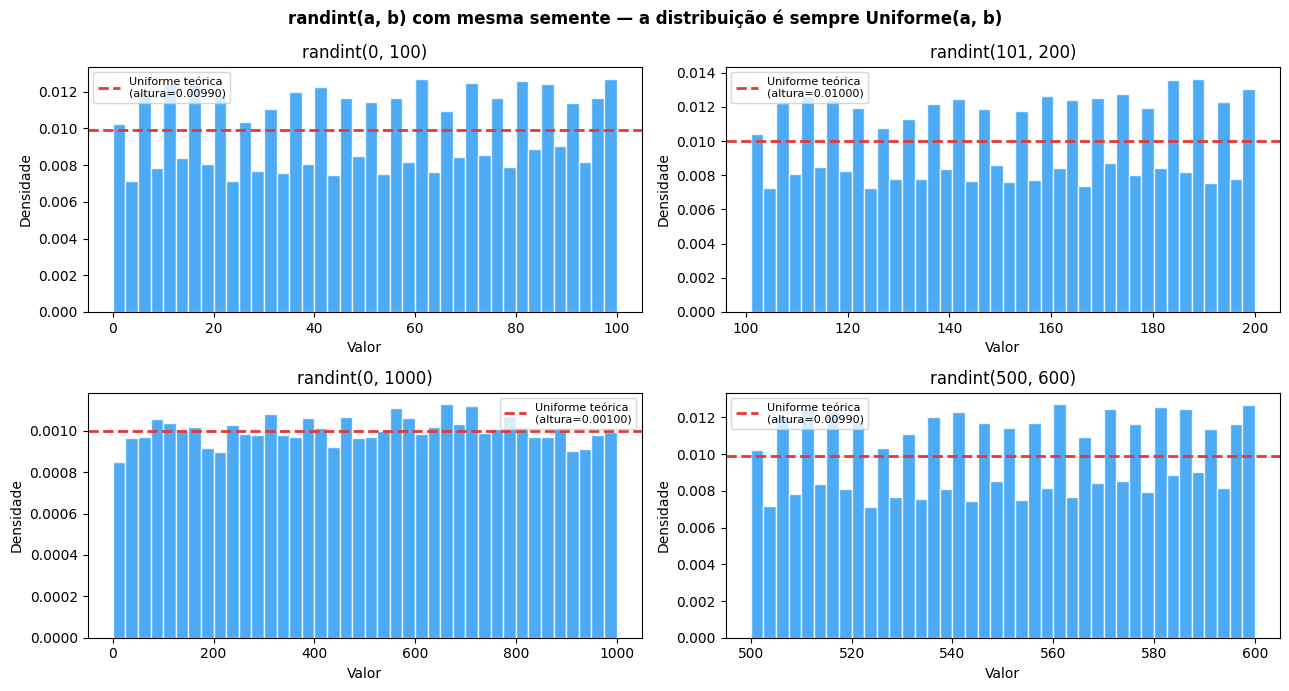

Observação: independente do intervalo, o histograma sempre se aproxima
da distribuição Uniforme — a forma não muda, apenas a escala.


In [13]:
N = 10_000
intervalos = [(0, 100), (101, 200), (0, 1000), (500, 600)]

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
fig.suptitle("randint(a, b) com mesma semente — a distribuição é sempre Uniforme(a, b)",
             fontweight='bold')

for ax, (a, b) in zip(axes.flat, intervalos):
    rng = random.Random(42)
    amostra = [rng.randint(a, b) for _ in range(N)]

    ax.hist(amostra, bins=40, color='#2196F3', alpha=0.8, edgecolor='white', density=True)

    # Linha da distribuição uniforme teórica
    altura_teorica = 1 / (b - a + 1)
    ax.axhline(altura_teorica, color='#E53935', linewidth=2,
               linestyle='--', label=f'Uniforme teórica\n(altura={altura_teorica:.5f})')

    ax.set_title(f'randint({a}, {b})')
    ax.set_xlabel('Valor')
    ax.set_ylabel('Densidade')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print("Observação: independente do intervalo, o histograma sempre se aproxima")
print("da distribuição Uniforme — a forma não muda, apenas a escala.")

## 1.2 — A correlação entre intervalos diferentes com a mesma semente

Como os valores de dois intervalos diferentes (mesma semente) vêm da **mesma fila interna**,
eles são correlacionados — um sobe quando o outro sobe.

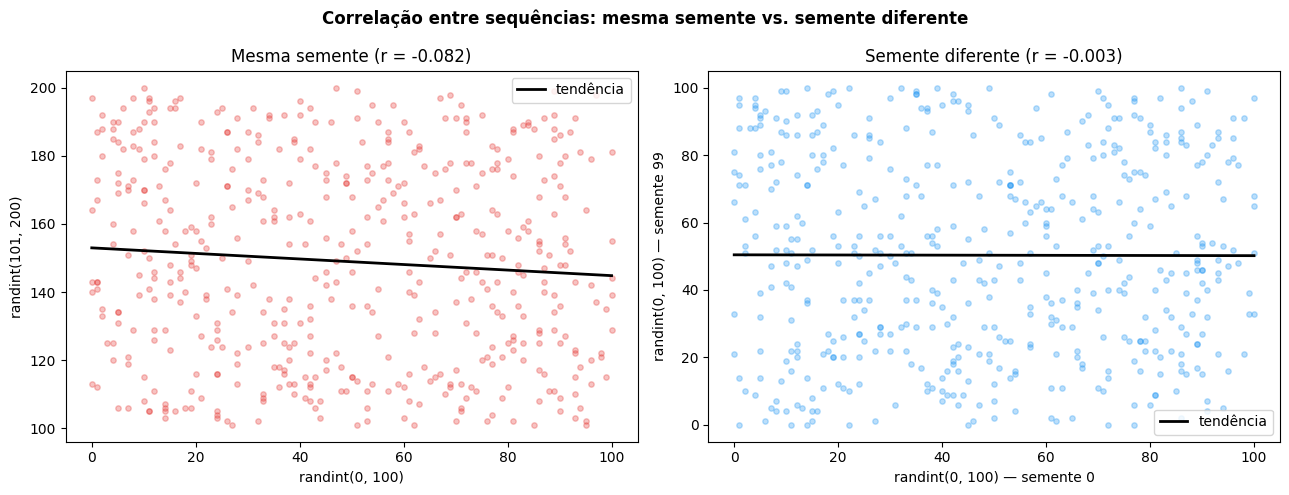

Correlação (mesma semente, intervalos diferentes): r = -0.0822
Correlação (sementes diferentes):                  r = -0.0025

→ A correlação próxima de 1 na esquerda revela que os dois intervalos
  são transformações lineares da mesma sequência interna.


In [17]:
N = 500

# Mesma semente, intervalos diferentes
rng_a = random.Random(0)
seq_0_100 = [rng_a.randint(0, 100) for _ in range(N)]

rng_b = random.Random(0)  # reinicia a mesma fila
seq_101_200 = [rng_b.randint(101, 200) for _ in range(N)]

# Semente diferente para comparação
rng_c = random.Random(99)
seq_independente = [rng_c.randint(0, 100) for _ in range(N)]

corr_mesma, _  = stats.pearsonr(seq_0_100, seq_101_200)
corr_dif, _    = stats.pearsonr(seq_0_100, seq_independente)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Correlação entre sequências: mesma semente vs. semente diferente",
             fontweight='bold')

# Plot 1: mesma semente
axes[0].scatter(seq_0_100, seq_101_200, alpha=0.3, s=15, color='#E53935')
axes[0].set_title(f'Mesma semente (r = {corr_mesma:.3f})')
axes[0].set_xlabel('randint(0, 100)')
axes[0].set_ylabel('randint(101, 200)')

# Linha de tendência
m, c = np.polyfit(seq_0_100, seq_101_200, 1)
xs = np.linspace(0, 100, 100)
axes[0].plot(xs, m * xs + c, color='black', linewidth=2, label=f'tendência')
axes[0].legend()

# Plot 2: semente diferente
axes[1].scatter(seq_0_100, seq_independente, alpha=0.3, s=15, color='#2196F3')
axes[1].set_title(f'Semente diferente (r = {corr_dif:.3f})')
axes[1].set_xlabel('randint(0, 100) — semente 0')
axes[1].set_ylabel('randint(0, 100) — semente 99')

m2, c2 = np.polyfit(seq_0_100, seq_independente, 1)
axes[1].plot(xs, m2 * xs + c2, color='black', linewidth=2, label='tendência')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Correlação (mesma semente, intervalos diferentes): r = {corr_mesma:.4f}")
print(f"Correlação (sementes diferentes):                  r = {corr_dif:.4f}")
print()
print("A correlação próxima de 1 na esquerda revela que os dois intervalos")
print("  são transformações lineares da mesma sequência interna.")

# Sequência (5 elementos)

In [20]:
seq5 = [4, 7, 2, 7, 9]

print("Sequência:", seq5)
print(f"Min:               {np.min(seq5)}")
print(f"Média (average):   {np.mean(seq5):.2f}")
print(f"Moda (mode):       {stats.mode(seq5).mode}")
print(f"Mediana:           {np.median(seq5)}")
print(f"Max:               {np.max(seq5)}")
print(f"Range:             {np.max(seq5) - np.min(seq5)}")
print(f"Soma (sum):        {np.sum(seq5)}")
print(f"Variância:         {np.var(seq5):.2f}")
print(f"Desvio padrão:     {np.std(seq5):.2f}")

Sequência: [4, 7, 2, 7, 9]
Min:               2
Média (average):   5.80
Moda (mode):       7
Mediana:           7.0
Max:               9
Range:             7
Soma (sum):        29
Variância:         6.16
Desvio padrão:     2.48


# Sequência (100 elementos)

In [23]:
rng = random.Random(42)
seq100 = [rng.randint(0, 100) for _ in range(100)]

print("Sequência:", seq100)
print(f"Min:               {np.min(seq100)}")
print(f"Média (average):   {np.mean(seq100):.2f}")
print(f"Moda (mode):       {stats.mode(seq100).mode}")
print(f"Mediana:           {np.median(seq100)}")
print(f"Max:               {np.max(seq100)}")
print(f"Range:             {np.max(seq100) - np.min(seq100)}")
print(f"Soma (sum):        {np.sum(seq100)}")
print(f"Variância:         {np.var(seq100):.2f}")
print(f"Desvio padrão:     {np.std(seq100):.2f}")

Sequência: [81, 14, 3, 94, 35, 31, 28, 17, 94, 13, 86, 94, 69, 11, 75, 54, 4, 3, 11, 27, 29, 64, 77, 3, 71, 25, 91, 83, 89, 69, 53, 28, 57, 75, 35, 0, 97, 20, 89, 54, 43, 35, 19, 27, 97, 43, 13, 11, 48, 12, 45, 44, 77, 33, 5, 93, 58, 68, 15, 48, 10, 70, 37, 80, 79, 46, 73, 24, 90, 8, 5, 84, 29, 98, 37, 10, 29, 12, 48, 35, 58, 81, 46, 20, 47, 45, 26, 85, 34, 89, 87, 82, 9, 77, 81, 21, 68, 93, 31, 20]
Min:               0
Média (average):   47.91
Moda (mode):       35
Mediana:           45.0
Max:               98
Range:             98
Soma (sum):        4791
Variância:         902.16
Desvio padrão:     30.04


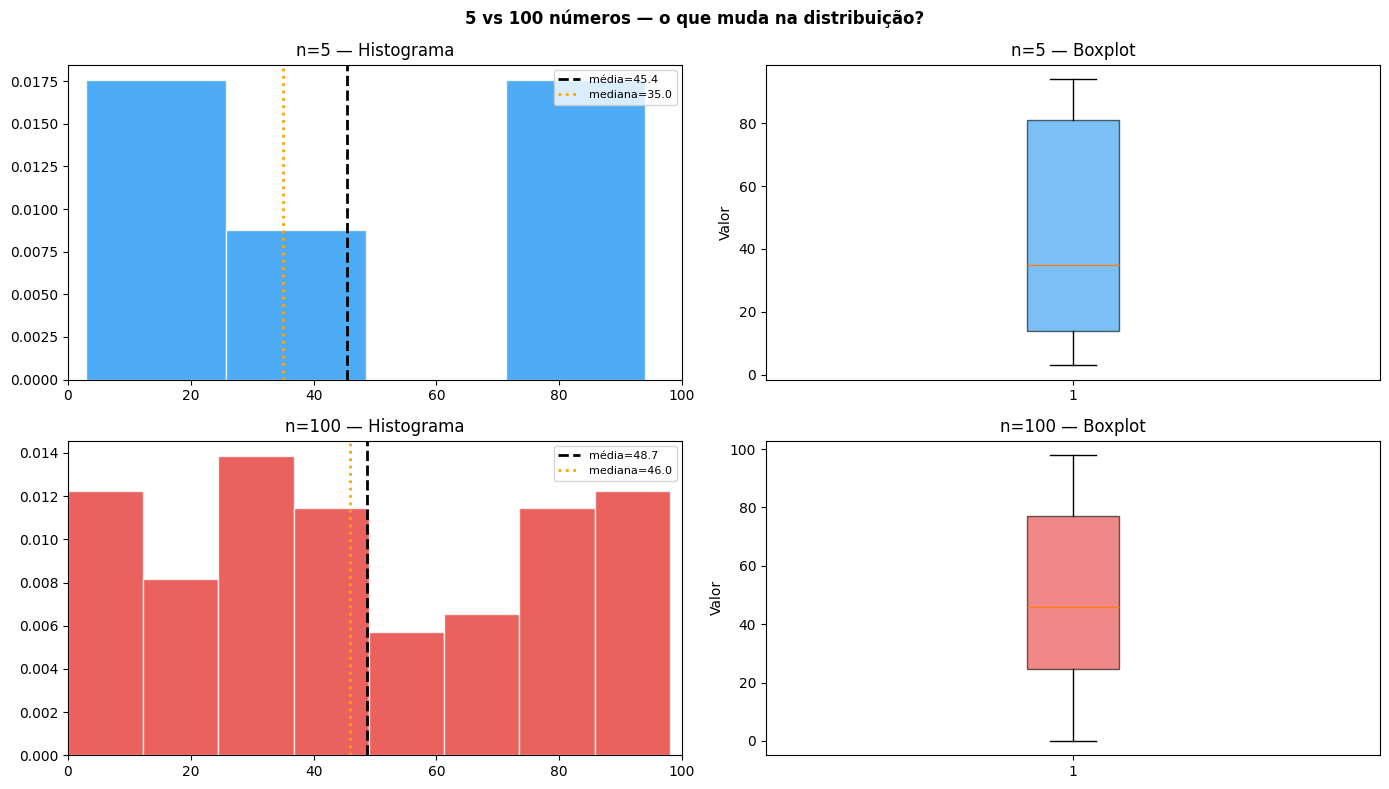

Métrica                     n=5      n=100
------------------------------------------
Min                        3.00       0.00
Max                       94.00      98.00
Range                     91.00      98.00
Média                     45.40      48.74
Mediana                   35.00      46.00
Desvio pad                36.11      29.43
P25                       14.00      24.75
P75                       81.00      77.00
IQR                       67.00      52.25


In [26]:
rng = random.Random(42)
seq5   = [rng.randint(0, 100) for _ in range(5)]
seq100 = [rng.randint(0, 100) for _ in range(100)]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("5 vs 100 números — o que muda na distribuição?", fontweight='bold')

for i, (seq, label) in enumerate([(seq5, "n=5"), (seq100, "n=100")]):
    media   = np.mean(seq)
    mediana = np.median(seq)
    dp      = np.std(seq)

    # Histograma
    axes[i][0].hist(seq, bins='auto', color='#2196F3' if i==0 else '#E53935',
                    edgecolor='white', density=True, alpha=0.8)
    axes[i][0].axvline(media,   color='black',  linestyle='--', linewidth=2, label=f'média={media:.1f}')
    axes[i][0].axvline(mediana, color='orange', linestyle=':',  linewidth=2, label=f'mediana={mediana:.1f}')
    axes[i][0].set_title(f"{label} — Histograma")
    axes[i][0].set_xlim(0, 100)
    axes[i][0].legend(fontsize=8)

    # Boxplot
    axes[i][1].boxplot(seq, vert=True, patch_artist=True,
                       boxprops=dict(facecolor='#2196F3' if i==0 else '#E53935', alpha=0.6))
    axes[i][1].set_title(f"{label} — Boxplot")
    axes[i][1].set_ylabel("Valor")

plt.tight_layout()
plt.show()

# Tabela comparativa
print(f"{'Métrica':<20} {'n=5':>10} {'n=100':>10}")
print("-" * 42)
metricas = [
    ("Min",        np.min(seq5),              np.min(seq100)),
    ("Max",        np.max(seq5),              np.max(seq100)),
    ("Range",      np.ptp(seq5),              np.ptp(seq100)),
    ("Média",      np.mean(seq5),             np.mean(seq100)),
    ("Mediana",    np.median(seq5),           np.median(seq100)),
    ("Desvio pad", np.std(seq5),              np.std(seq100)),
    ("P25",        np.percentile(seq5,  25),  np.percentile(seq100,  25)),
    ("P75",        np.percentile(seq5,  75),  np.percentile(seq100,  75)),
    ("IQR",        np.percentile(seq5,  75) - np.percentile(seq5,  25),
                   np.percentile(seq100, 75) - np.percentile(seq100, 25)),
]
for nome, v5, v100 in metricas:
    print(f"{nome:<20} {v5:>10.2f} {v100:>10.2f}")

# Distribuição com controle de bins + percentis

Bins: o histograma não é a distribuição é uma escolha de representação. O número de bins controla a resolução com que você enxerga os dados. Poucos bins escondem estrutura; muitos bins criam ruído visual. O conceito é que a mesma amostra pode parecer diferente dependendo de como você a agrupa.


Percentis: dividem a distribuição em partes de igual probabilidade. O P25 e P75, por exemplo, delimitam os 50% centrais dos dados. A distância entre eles (IQR) é uma medida de dispersão robusta a outliers diferente do desvio padrão, que é sensível a extremos.

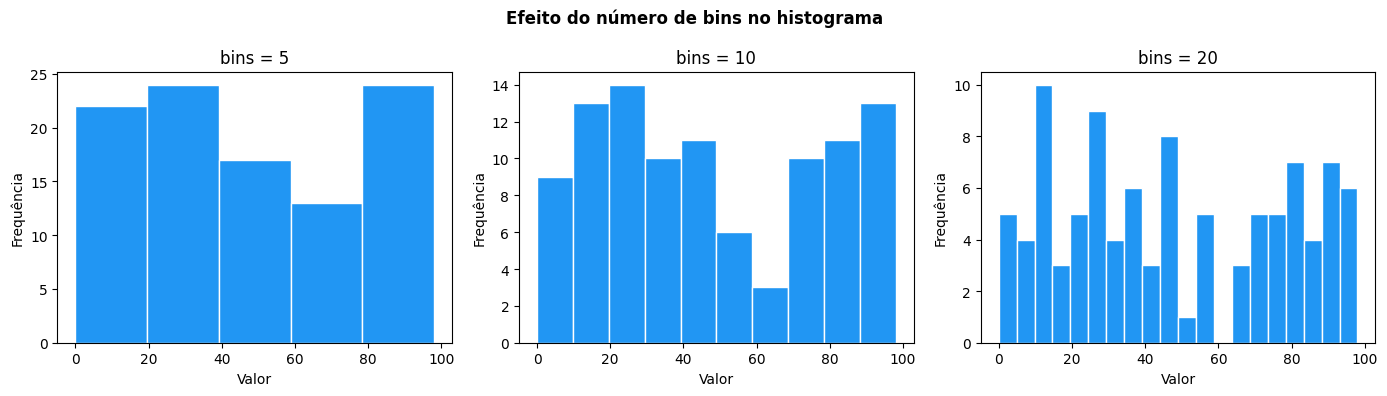


Percentis:
  P10: 10.0
  P25: 20.8
  P50: 45.0
  P75: 77.0
  P90: 89.1


In [19]:
import numpy as np
import matplotlib.pyplot as plt
import random

rng = random.Random(42)
seq100 = [rng.randint(0, 100) for _ in range(100)]

# --- Distribuição controlando bins ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Efeito do número de bins no histograma", fontweight='bold')

for ax, bins in zip(axes, [5, 10, 20]):
    ax.hist(seq100, bins=bins, color='#2196F3', edgecolor='white')
    ax.set_title(f"bins = {bins}")
    ax.set_xlabel("Valor")
    ax.set_ylabel("Frequência")

plt.tight_layout()
plt.show()

# --- Percentis ---
percentis = [10, 25, 50, 75, 90]
print("\nPercentis:")
for p in percentis:
    print(f"  P{p:2d}: {np.percentile(seq100, p):.1f}")

# Média como soma ponderada

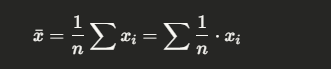

Quando os pesos diferem, cada observação contribui proporcionalmente ao seu peso. 

O conceito central é que a média não trata todas as observações como igualmente importantes por natureza. Quando você atribui pesos iguais, está fazendo uma suposição explícita sobre a relevância de cada dado.

Sequência: [4, 7, 2, 7, 9]
Pesos iguais:      [0.2, 0.2, 0.2, 0.2, 0.2]
Média ponderada:   5.80
np.mean():         5.80

Pesos customizados: [0.1, 0.1, 0.1, 0.3, 0.4]  (soma = 1.0)
Média ponderada:    7.00  ← influenciada pelos pesos maiores



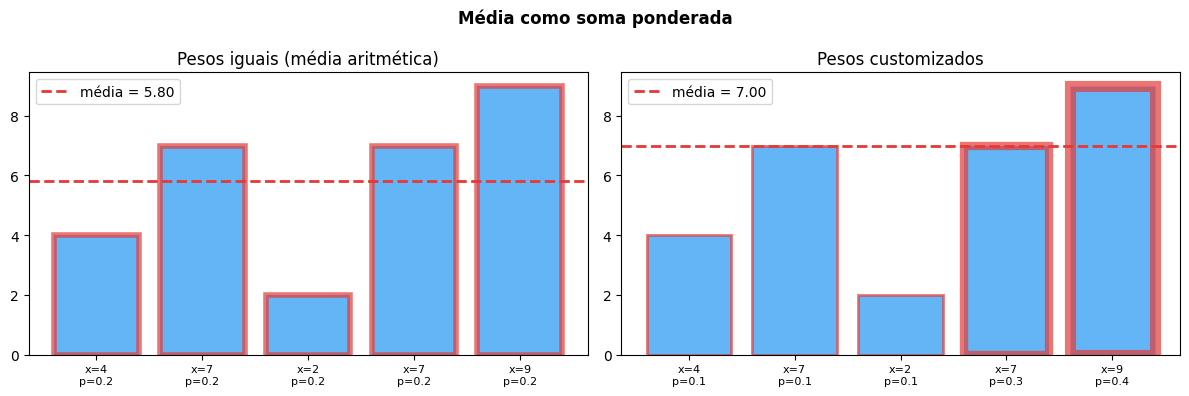

In [28]:
import numpy as np

seq = [4, 7, 2, 7, 9]
n = len(seq)

# Pesos iguais → média aritmética comum
pesos_iguais = [1/n] * n
media_ponderada = sum(p * x for p, x in zip(pesos_iguais, seq))

print("Sequência:", seq)
print(f"Pesos iguais:      {pesos_iguais}")
print(f"Média ponderada:   {media_ponderada:.2f}")
print(f"np.mean():         {np.mean(seq):.2f}")
print()

# Pesos diferentes → destaca certos valores
pesos_custom = [0.1, 0.1, 0.1, 0.3, 0.4]  # últimos valores têm mais peso
media_custom = sum(p * x for p, x in zip(pesos_custom, seq))

print(f"Pesos customizados: {pesos_custom}  (soma = {sum(pesos_custom)})")
print(f"Média ponderada:    {media_custom:.2f}  ← influenciada pelos pesos maiores")
print()

# Visualização
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Média como soma ponderada", fontweight='bold')

for ax, pesos, titulo in zip(axes,
    [pesos_iguais, pesos_custom],
    ["Pesos iguais (média aritmética)", "Pesos customizados"]):

    media = sum(p * x for p, x in zip(pesos, seq))
    bars = ax.bar(range(n), seq, color='#2196F3', alpha=0.7, edgecolor='white')

    # Largura das barras proporcional ao peso
    for bar, peso in zip(bars, pesos):
        bar.set_linewidth(peso * 20)
        bar.set_edgecolor('#E53935')

    ax.axhline(media, color='#E53935', linewidth=2,
               linestyle='--', label=f'média = {media:.2f}')
    ax.set_xticks(range(n))
    ax.set_xticklabels([f"x={v}\np={p}" for v, p in zip(seq, pesos)], fontsize=8)
    ax.set_title(titulo)
    ax.legend()

plt.tight_layout()
plt.show()

# Série Temporal


Série temporal — mostra a evolução dos valores no tempo. Como os números são aleatórios, não há tendência nem sazonalidade o que você vê é ruído puro. A linha da média corta o gráfico aproximadamente no centro.


Barras o mesmo dado visto como magnitude em cada instante. A coloração por acima/abaixo da média torna imediato ver se há concentração de valores altos ou baixos em alguma região do tempo.


Pizza perde a dimensão temporal mas ganha proporção. Mostra se os valores se distribuem equilibradamente entre as quatro faixas — o esperado numa Uniforme(0,100) é ~25% em cada fatia.

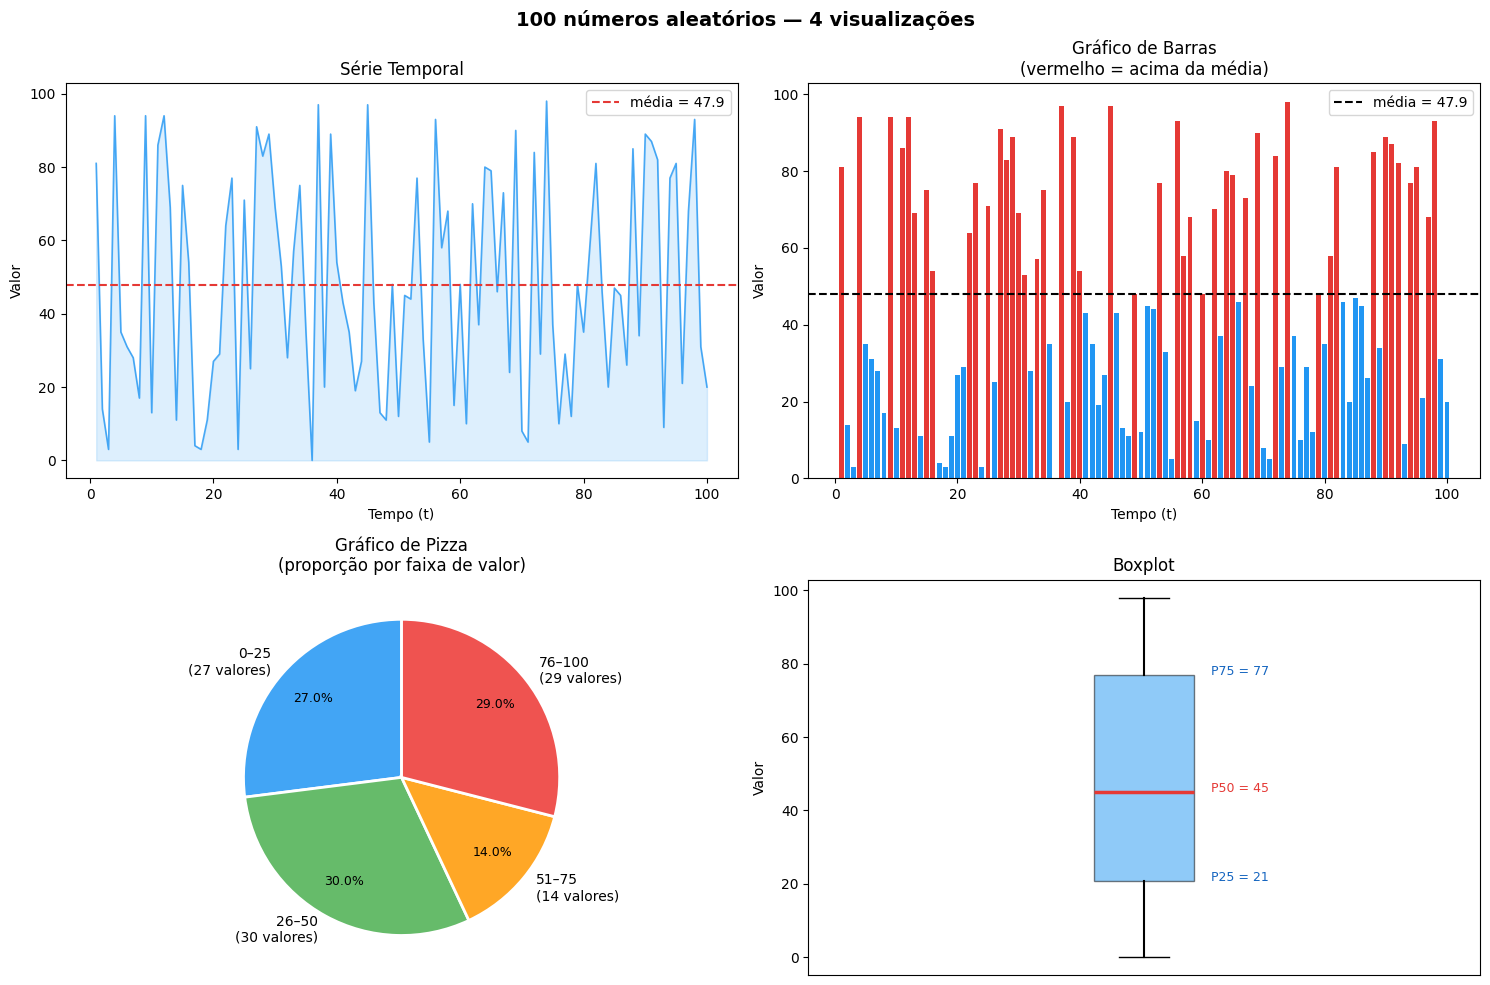

Média:      47.91
Mediana:    45.00
Desvio pad: 30.04
Min / Max:  0 / 98

Distribuição por faixa:
  0–25: 27 valores (27%)
  26–50: 30 valores (30%)
  51–75: 14 valores (14%)
  76–100: 29 valores (29%)


In [32]:
rng = random.Random(42)
valores = [rng.randint(0, 100) for _ in range(100)]
tempo   = list(range(1, 101))

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("100 números aleatórios — 4 visualizações", fontweight='bold', fontsize=14)

# --- 1. Série Temporal ---
ax1 = axes[0][0]
ax1.plot(tempo, valores, color='#2196F3', linewidth=1.2, alpha=0.8)
ax1.fill_between(tempo, valores, alpha=0.15, color='#2196F3')
ax1.axhline(np.mean(valores), color='#E53935', linestyle='--',
            linewidth=1.5, label=f'média = {np.mean(valores):.1f}')
ax1.set_title("Série Temporal")
ax1.set_xlabel("Tempo (t)")
ax1.set_ylabel("Valor")
ax1.legend()

# --- 2. Gráfico de Barras ---
ax2 = axes[0][1]
cores = ['#E53935' if v > np.mean(valores) else '#2196F3' for v in valores]
ax2.bar(tempo, valores, color=cores, edgecolor='none', width=0.8)
ax2.axhline(np.mean(valores), color='black', linestyle='--',
            linewidth=1.5, label=f'média = {np.mean(valores):.1f}')
ax2.set_title("Gráfico de Barras\n(vermelho = acima da média)")
ax2.set_xlabel("Tempo (t)")
ax2.set_ylabel("Valor")
ax2.legend()

# --- 3. Gráfico de Pizza ---
ax3 = axes[1][0]
bins_pizza  = [0, 25, 50, 75, 100]
labels      = ['0–25', '26–50', '51–75', '76–100']
cores_pizza = ['#42A5F5', '#66BB6A', '#FFA726', '#EF5350']
contagens   = np.histogram(valores, bins=bins_pizza)[0]

wedges, texts, autotexts = ax3.pie(
    contagens,
    labels=[f"{l}\n({c} valores)" for l, c in zip(labels, contagens)],
    colors=cores_pizza,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(9)
ax3.set_title("Gráfico de Pizza\n(proporção por faixa de valor)")

# --- 4. Boxplot ---
ax4 = axes[1][1]
bp = ax4.boxplot(valores, vert=True, patch_artist=True,
                 boxprops=dict(facecolor='#2196F3', alpha=0.5),
                 medianprops=dict(color='#E53935', linewidth=2.5),
                 whiskerprops=dict(linewidth=1.5),
                 flierprops=dict(marker='o', markerfacecolor='#E53935',
                                 markersize=6, alpha=0.6))

p25 = np.percentile(valores, 25)
p50 = np.percentile(valores, 50)
p75 = np.percentile(valores, 75)
ax4.annotate(f'P75 = {p75:.0f}', xy=(1.1, p75), fontsize=9, color='#1565C0')
ax4.annotate(f'P50 = {p50:.0f}', xy=(1.1, p50), fontsize=9, color='#E53935')
ax4.annotate(f'P25 = {p25:.0f}', xy=(1.1, p25), fontsize=9, color='#1565C0')
ax4.set_title("Boxplot")
ax4.set_ylabel("Valor")
ax4.set_xticks([])

plt.tight_layout()
plt.show()

# Resumo
print(f"Média:      {np.mean(valores):.2f}")
print(f"Mediana:    {np.median(valores):.2f}")
print(f"Desvio pad: {np.std(valores):.2f}")
print(f"Min / Max:  {min(valores)} / {max(valores)}")
print(f"\nDistribuição por faixa:")
for l, c in zip(labels, contagens):
    print(f"  {l}: {c} valores ({c}%)")

## Interpretação geométrica das estatísticas descritivas

---

### Mínimo e Máximo

Imagine todos os seus dados como pontos numa reta numérica. O **mínimo** é o ponto mais à esquerda e o **máximo** é o ponto mais à direita — eles definem as **fronteiras do território** que os dados ocupam.


Sozinhos dizem pouco sobre o interior — dois conjuntos com o mesmo mínimo e máximo podem ter formas completamente diferentes por dentro.


### Range (amplitude)

O range é o **comprimento do segmento** entre mínimo e máximo:


É a medida de dispersão mais intuitiva — o tamanho do território. Sua fraqueza: depende exclusivamente dos dois extremos. Um único outlier infla o range sem que o "corpo" dos dados tenha se movido.

---

### Soma

A soma é a **área total** de um conjunto de barras de largura 1 e altura igual a cada valor:


É o "bolo inteiro" que será dividido igualmente para calcular a média.

---

### Média

A média é o ponto de **equilíbrio** — o fulcro onde a distribuição ficaria balanceada numa gangorra:

Valores distantes do centro puxam mais — um único outlier desloca a média significativamente. A média **minimiza a soma dos desvios ao quadrado** — nenhum outro ponto tem essa propriedade.

---

### Mediana

A mediana é o **ponto que divide a distribuição em duas metades iguais** — 50% das observações à esquerda, 50% à direita:


A diferença geométrica fundamental entre média e mediana:

- A **média responde à distância** — valores extremos a deslocam
- A **mediana responde à posição relativa** — só importa se o ponto está à esquerda ou à direita do corte

Por isso a mediana é robusta a outliers: substituir o valor 9 por 9000 não move a mediana, mas destrói a média.

---

### Variância

A variância é a **área média dos quadrados** construídos sobre os desvios de cada ponto em relação à média:



A variância é a **média dessas áreas** sobre todos os pontos. O uso do quadrado tem duas consequências geométricas:

- Penaliza desvios grandes desproporcionalmente — um desvio duplo gera área quádrupla
- Garante que desvios positivos e negativos não se cancelem

A unidade da variância é o **quadrado da unidade original** — se os dados estão em metros, a variância está em m². Isso a torna difícil de interpretar diretamente na escala dos dados.

---

### Desvio Padrão

O desvio padrão é a raiz quadrada da variância — geometricamente, é o **lado do quadrado cuja área é igual à variância**:

Voltando à escala original, o desvio padrão é a **distância típica** de uma observação em relação à média. Numa distribuição normal:




In [39]:
print(x, dados)

[0 1 2 3 4 5 6 7 8 9] [ 2  4  4  5  7  7  7  9 10 15]


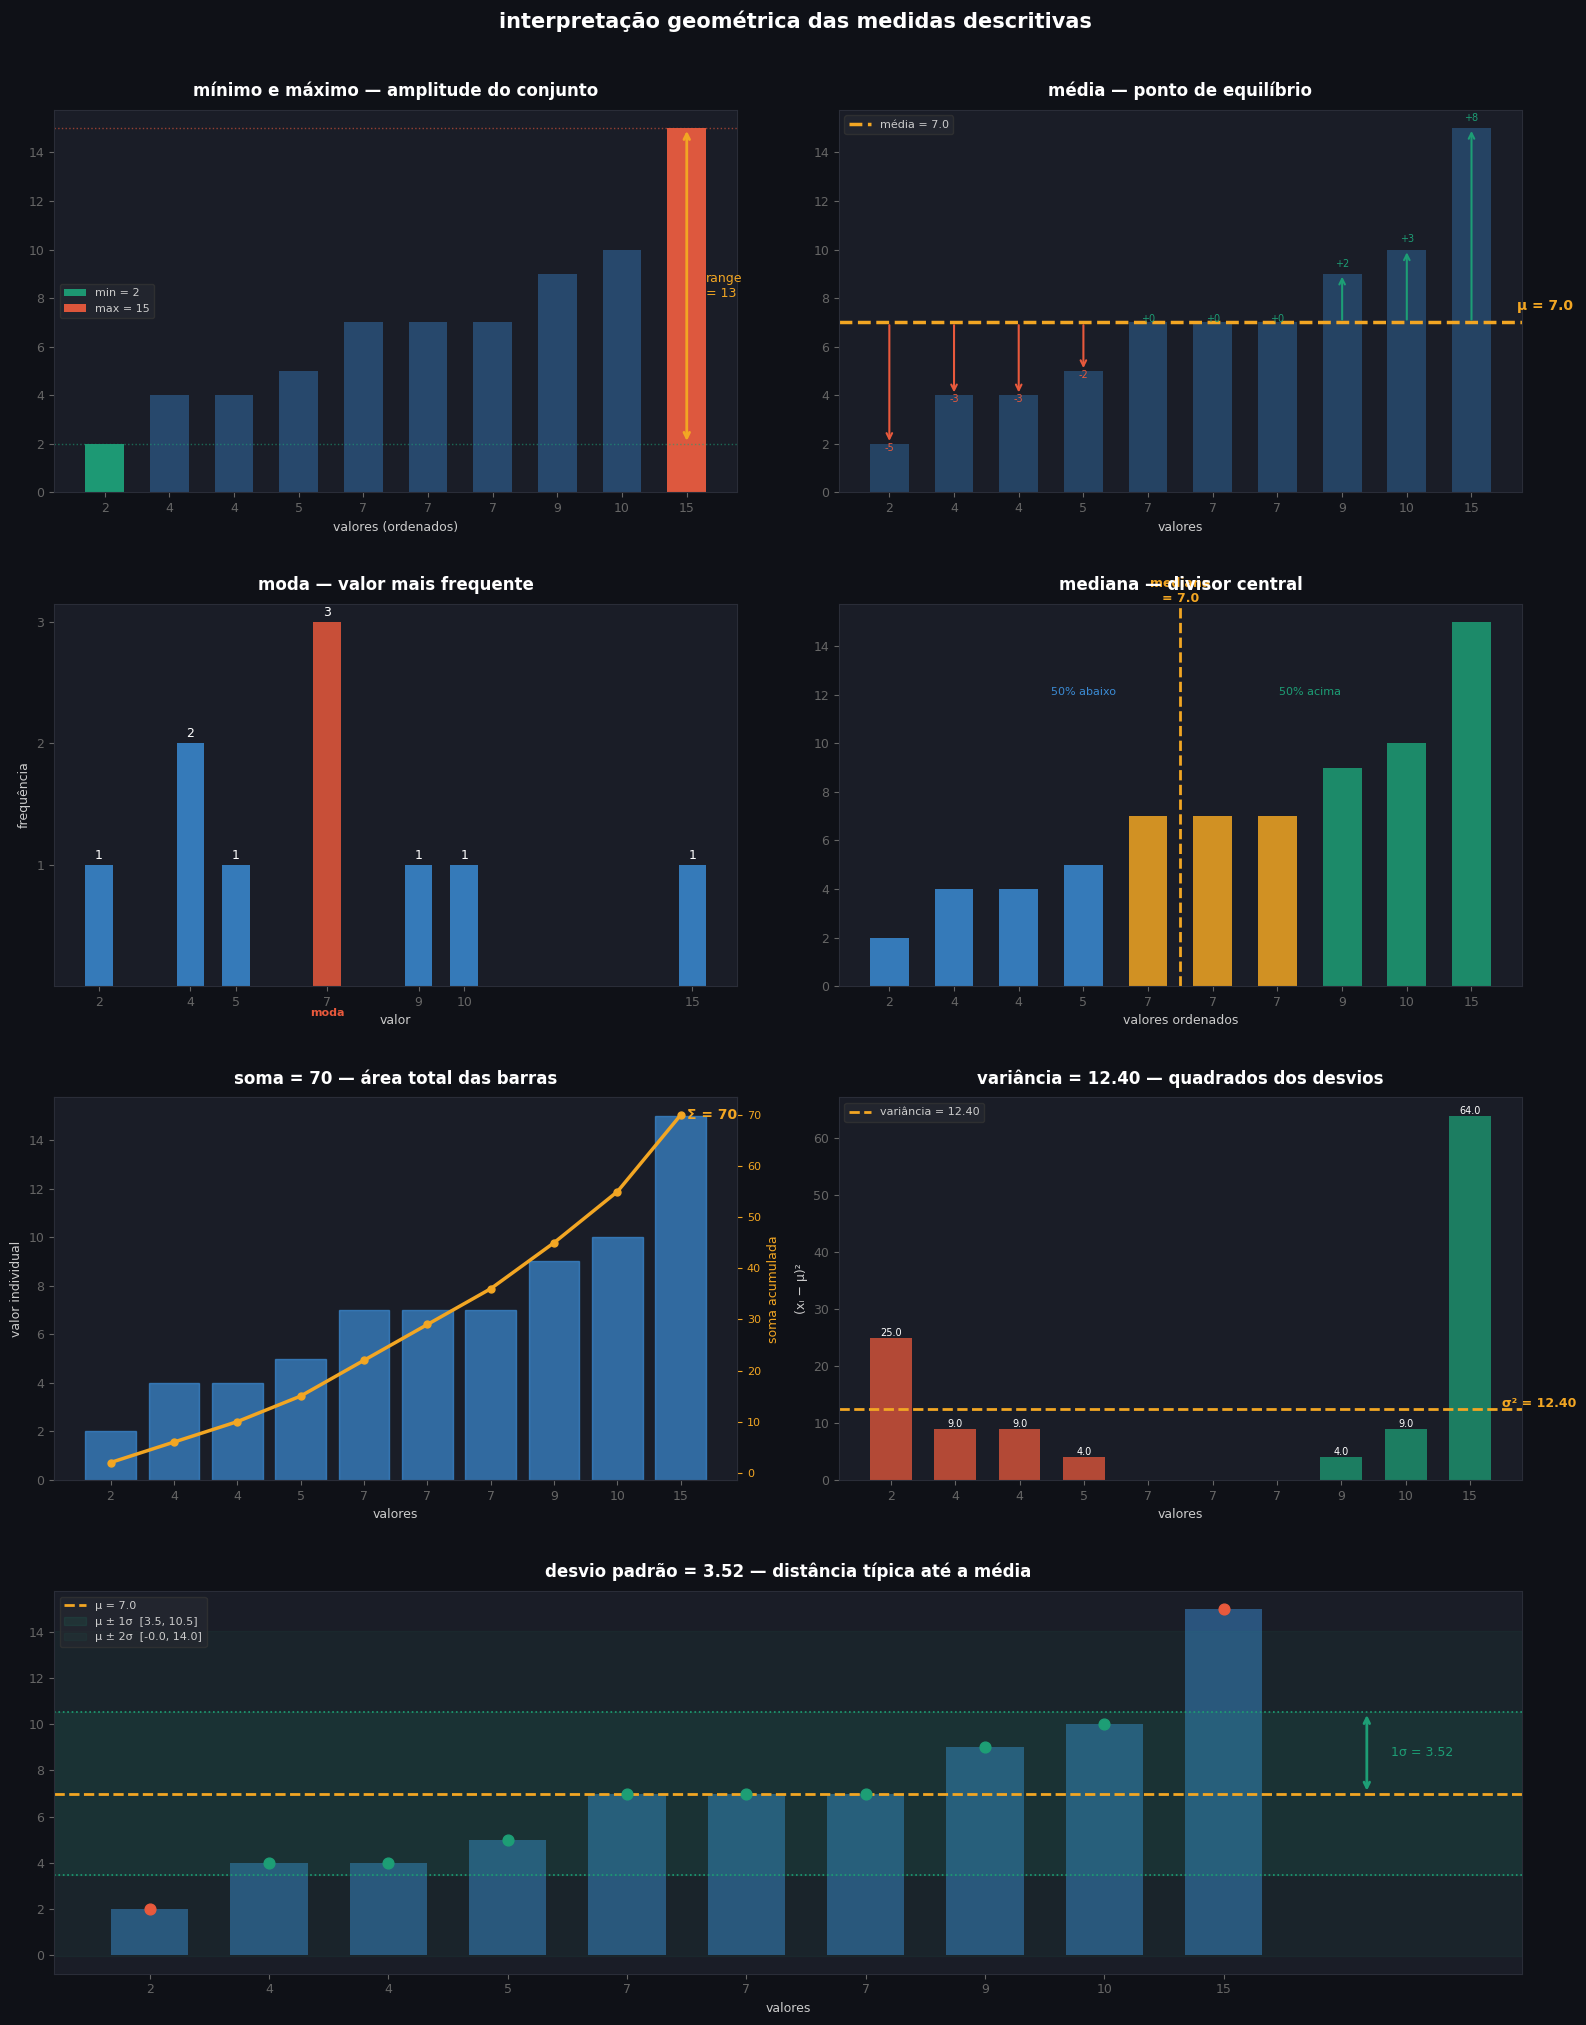

In [44]:

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch


# Dados
np.random.seed(42)
dados = np.array([2, 4, 4, 5, 7, 7, 7, 9, 10, 15])
n     = len(dados)
x     = np.arange(n)

# Estatísticas
minimo   = np.min(dados)
maximo   = np.max(dados)
media    = np.mean(dados)
mediana  = np.median(dados)
moda_val = stats.mode(dados).mode
soma     = np.sum(dados)
variancia= np.var(dados)
dp       = np.std(dados)

fig = plt.figure(figsize=(16, 20))
fig.patch.set_facecolor('#0f1117')
TITULO = dict(color='white', fontsize=12, fontweight='bold', pad=10)
COR_BARRA  = '#3B8BD4'
COR_DESTAQUE = '#E8593C'
COR_VERDE  = '#1D9E75'
COR_AMBER  = '#F2A623'
COR_TEXTO  = '#cccccc'

def ax_style(ax, title):
    ax.set_facecolor('#1a1d27')
    ax.tick_params(colors='#666', labelsize=9)
    for spine in ax.spines.values():
        spine.set_edgecolor('#2a2d38')
    ax.set_title(title, **TITULO)

# ─────────────────────────────────────────────
# 1. MÍNIMO e MÁXIMO — linha de amplitude
# ─────────────────────────────────────────────
ax1 = fig.add_subplot(4, 2, 1)
ax_style(ax1, 'mínimo e máximo — amplitude do conjunto')
ax1.bar(x, dados, color=COR_BARRA, alpha=0.4, width=0.6)
ax1.bar([x[np.argmin(dados)]], [minimo], color=COR_VERDE,  alpha=0.95, width=0.6, label=f'min = {minimo}')
ax1.bar([x[np.argmax(dados)]], [maximo], color=COR_DESTAQUE, alpha=0.95, width=0.6, label=f'max = {maximo}')

# Seta de amplitude
ax1.annotate('', xy=(x[-1], maximo), xytext=(x[-1], minimo),
             arrowprops=dict(arrowstyle='<->', color=COR_AMBER, lw=2))
ax1.text(x[-1]+0.3, (maximo+minimo)/2,
         f'range\n= {maximo-minimo}', color=COR_AMBER, fontsize=9, va='center')
ax1.axhline(minimo, color=COR_VERDE,    linestyle=':', linewidth=1, alpha=0.6)
ax1.axhline(maximo, color=COR_DESTAQUE, linestyle=':', linewidth=1, alpha=0.6)
ax1.set_xticks(x); ax1.set_xticklabels(dados)
ax1.set_xlabel('valores (ordenados)', color=COR_TEXTO, fontsize=9)
ax1.legend(fontsize=8, facecolor='#252830', labelcolor='#ccc', edgecolor='#333')

# ─────────────────────────────────────────────
# 2. MÉDIA — ponto de equilíbrio (alavanca)
# ─────────────────────────────────────────────
ax2 = fig.add_subplot(4, 2, 2)
ax_style(ax2, 'média — ponto de equilíbrio')

desvios = dados - media
cores_dev = [COR_VERDE if d >= 0 else COR_DESTAQUE for d in desvios]
ax2.bar(x, dados, color=COR_BARRA, alpha=0.35, width=0.6)
for i, (xi, di, cor) in enumerate(zip(x, desvios, cores_dev)):
    ax2.annotate('', xy=(xi, media + di), xytext=(xi, media),
                 arrowprops=dict(arrowstyle='->', color=cor, lw=1.5))
    ax2.text(xi, media + di + 0.3*np.sign(di),
             f'{di:+.0f}', ha='center', color=cor, fontsize=7)

ax2.axhline(media, color=COR_AMBER, linewidth=2.5, linestyle='--',
            label=f'média = {media:.1f}')
ax2.text(n-0.3, media+0.5, f'μ = {media:.1f}', color=COR_AMBER, fontsize=10, fontweight='bold')
ax2.set_xticks(x); ax2.set_xticklabels(dados)
ax2.set_xlabel('valores', color=COR_TEXTO, fontsize=9)
ax2.legend(fontsize=8, facecolor='#252830', labelcolor='#ccc', edgecolor='#333')

# ─────────────────────────────────────────────
# 3. MODA — frequência de repetição
# ─────────────────────────────────────────────
ax3 = fig.add_subplot(4, 2, 3)
ax_style(ax3, 'moda — valor mais frequente')
valores_unicos, frequencias = np.unique(dados, return_counts=True)
cores_moda = [COR_DESTAQUE if v == moda_val else COR_BARRA for v in valores_unicos]
bars = ax3.bar(valores_unicos, frequencias, color=cores_moda,
               alpha=0.85, width=0.6, edgecolor='none')
for bar, freq, val in zip(bars, frequencias, valores_unicos):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             str(freq), ha='center', color='white', fontsize=9)
    if val == moda_val:
        ax3.text(bar.get_x() + bar.get_width()/2, -0.25,
                 'moda', ha='center', color=COR_DESTAQUE, fontsize=8, fontweight='bold')

ax3.set_xlabel('valor', color=COR_TEXTO, fontsize=9)
ax3.set_ylabel('frequência', color=COR_TEXTO, fontsize=9)
ax3.set_xticks(valores_unicos)
ax3.set_yticks([1, 2, 3])

# ─────────────────────────────────────────────
# 4. MEDIANA — divisor do meio
# ─────────────────────────────────────────────
ax4 = fig.add_subplot(4, 2, 4)
ax_style(ax4, 'mediana — divisor central')
dados_ord = np.sort(dados)
meio = n // 2
cores_med = []
for i, v in enumerate(dados_ord):
    if v == mediana:  cores_med.append(COR_AMBER)
    elif i < meio:    cores_med.append(COR_BARRA)
    else:             cores_med.append(COR_VERDE)

ax4.bar(range(n), dados_ord, color=cores_med, alpha=0.85, width=0.6)
ax4.axvline(meio - 0.5, color=COR_AMBER, linewidth=2, linestyle='--')

# Anotação 50/50
ax4.annotate('50% abaixo', xy=(meio-2, 12), ha='center', color=COR_BARRA, fontsize=8)
ax4.annotate('50% acima', xy=(meio+1.5, 12), ha='center', color=COR_VERDE, fontsize=8)
ax4.text(meio-0.5, maximo+0.8, f'mediana\n= {mediana}',
         ha='center', color=COR_AMBER, fontsize=9, fontweight='bold')
ax4.set_xticks(range(n)); ax4.set_xticklabels(dados_ord)
ax4.set_xlabel('valores ordenados', color=COR_TEXTO, fontsize=9)

# ─────────────────────────────────────────────
# 5. SOMA — área acumulada
# ─────────────────────────────────────────────
ax5 = fig.add_subplot(4, 2, 5)
ax_style(ax5, f'soma = {soma} — área total das barras')
ax5.bar(x, dados, color=COR_BARRA, alpha=0.7, width=0.8, edgecolor='#3B8BD480')

# Linha acumulada
acumulado = np.cumsum(dados)
ax5_twin = ax5.twinx()
ax5_twin.plot(x, acumulado, color=COR_AMBER, linewidth=2.5,
              marker='o', markersize=5, zorder=3)
ax5_twin.set_ylabel('soma acumulada', color=COR_AMBER, fontsize=9)
ax5_twin.tick_params(colors=COR_AMBER, labelsize=8)
ax5_twin.set_facecolor('#1a1d27')
for spine in ax5_twin.spines.values():
    spine.set_edgecolor('#2a2d38')

ax5_twin.text(n-1+0.1, soma, f'Σ = {soma}',
              color=COR_AMBER, fontsize=10, fontweight='bold', va='center')
ax5.set_xticks(x); ax5.set_xticklabels(dados)
ax5.set_xlabel('valores', color=COR_TEXTO, fontsize=9)
ax5.set_ylabel('valor individual', color=COR_TEXTO, fontsize=9)

# ─────────────────────────────────────────────
# 6. VARIÂNCIA — quadrados dos desvios
# ─────────────────────────────────────────────
ax6 = fig.add_subplot(4, 2, 6)
ax_style(ax6, f'variância = {variancia:.2f} — quadrados dos desvios')
desvios_sq = (dados - media) ** 2
cores_var = [COR_VERDE if d >= 0 else COR_DESTAQUE for d in (dados - media)]
ax6.bar(x, desvios_sq, color=cores_var, alpha=0.75, width=0.65)

for i, (xi, dsq) in enumerate(zip(x, desvios_sq)):
    if dsq > 1:
        ax6.text(xi, dsq + 0.3, f'{dsq:.1f}', ha='center', color='white', fontsize=7)

ax6.axhline(variancia, color=COR_AMBER, linewidth=2, linestyle='--',
            label=f'variância = {variancia:.2f}')
ax6.text(n-0.5, variancia+0.5, f'σ² = {variancia:.2f}',
         color=COR_AMBER, fontsize=9, fontweight='bold')
ax6.set_xticks(x); ax6.set_xticklabels(dados)
ax6.set_xlabel('valores', color=COR_TEXTO, fontsize=9)
ax6.set_ylabel('(xᵢ − μ)²', color=COR_TEXTO, fontsize=9)
ax6.legend(fontsize=8, facecolor='#252830', labelcolor='#ccc', edgecolor='#333')

# ─────────────────────────────────────────────
# 7. DESVIO PADRÃO — faixa em torno da média
# ─────────────────────────────────────────────
ax7 = fig.add_subplot(4, 1, 4)
ax_style(ax7, f'desvio padrão = {dp:.2f} — distância típica até a média')

ax7.bar(x, dados, color=COR_BARRA, alpha=0.5, width=0.65)
ax7.axhline(media, color=COR_AMBER, linewidth=2, linestyle='--', label=f'μ = {media:.1f}')

# Faixa ±1σ
ax7.axhspan(media - dp, media + dp,
            alpha=0.12, color=COR_VERDE, label=f'μ ± 1σ  [{media-dp:.1f}, {media+dp:.1f}]')
ax7.axhline(media + dp, color=COR_VERDE, linewidth=1.2, linestyle=':')
ax7.axhline(media - dp, color=COR_VERDE, linewidth=1.2, linestyle=':')

# Faixa ±2σ
ax7.axhspan(media - 2*dp, media + 2*dp,
            alpha=0.06, color=COR_VERDE, label=f'μ ± 2σ  [{media-2*dp:.1f}, {media+2*dp:.1f}]')

# Seta de 1σ
ax7.annotate('', xy=(n+0.2, media + dp), xytext=(n+0.2, media),
             arrowprops=dict(arrowstyle='<->', color=COR_VERDE, lw=2))
ax7.text(n+0.4, media + dp/2, f'1σ = {dp:.2f}',
         color=COR_VERDE, fontsize=9, va='center')

# Pontos dentro/fora de 1σ
for xi, v in zip(x, dados):
    cor = COR_VERDE if abs(v - media) <= dp else COR_DESTAQUE
    ax7.scatter(xi, v, color=cor, s=60, zorder=5)

ax7.set_xticks(x); ax7.set_xticklabels(dados)
ax7.set_xlabel('valores', color=COR_TEXTO, fontsize=9)
ax7.set_xlim(-0.8, n+1.5)
ax7.legend(fontsize=8, facecolor='#252830', labelcolor='#ccc',
           edgecolor='#333', loc='upper left')

plt.suptitle('interpretação geométrica das medidas descritivas',
             color='white', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout(h_pad=3)
plt.show()

# Máximo e Mínimo

Caso curioso: mínimo e máximo são sempre elementos do conjunto original não podem ser valores inventados. O domínio é o conjunto inteiro; a imagem é um subconjunto de tamanho 1.


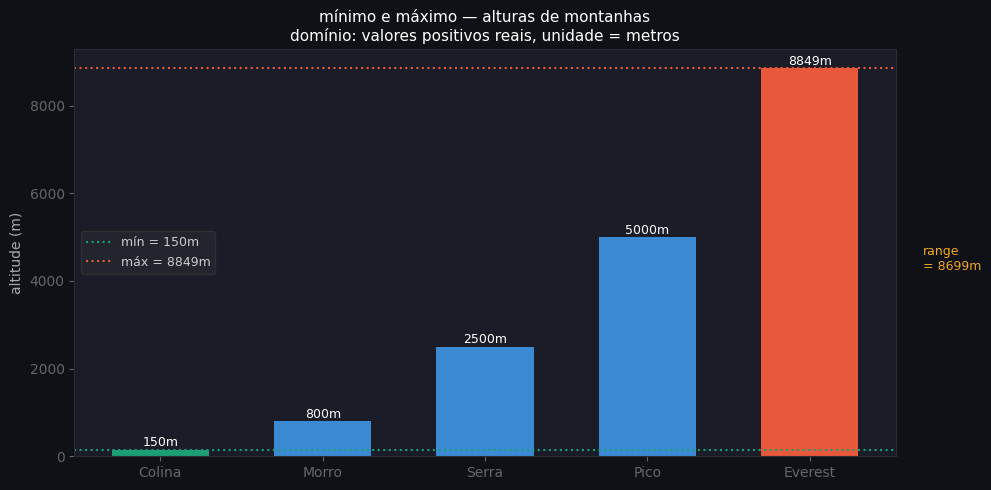

── Mínimo e Máximo ──────────────────────────
Conjunto : [150, 800, 2500, 5000, 8849]
Mínimo   : 150m  → menor altitude
Máximo   : 8849m → maior altitude
Domínio  : ℝ⁺ — qualquer valor real positivo
Imagem   : sempre um elemento do próprio conjunto


In [45]:


montanhas = ['Colina', 'Morro', 'Serra', 'Pico', 'Everest']
alturas   = [150, 800, 2500, 5000, 8849]

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d27')

cores = ['#3B8BD4'] * len(alturas)
cores[np.argmin(alturas)] = '#1D9E75'   # mínimo → verde
cores[np.argmax(alturas)] = '#E8593C'   # máximo → vermelho

bars = ax.bar(montanhas, alturas, color=cores, width=0.6, edgecolor='none')

for bar, val in zip(bars, alturas):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
            f'{val}m', ha='center', color='white', fontsize=9)

ax.axhline(min(alturas), color='#1D9E75', linestyle=':', linewidth=1.5,
           label=f'mín = {min(alturas)}m')
ax.axhline(max(alturas), color='#E8593C', linestyle=':', linewidth=1.5,
           label=f'máx = {max(alturas)}m')

ax.annotate('', xy=(4.6, max(alturas)), xytext=(4.6, min(alturas)),
            arrowprops=dict(arrowstyle='<->', color='#F2A623', lw=2))
ax.text(4.7, (max(alturas)+min(alturas))/2,
        f'range\n= {max(alturas)-min(alturas)}m',
        color='#F2A623', fontsize=9, va='center')

ax.set_ylabel('altitude (m)', color='#aaa')
ax.set_title('mínimo e máximo — alturas de montanhas\n'
             'domínio: valores positivos reais, unidade = metros',
             color='white', fontsize=11)
ax.tick_params(colors='#666')
for spine in ax.spines.values(): spine.set_edgecolor('#2a2d38')
ax.legend(fontsize=9, facecolor='#252830', labelcolor='#ccc', edgecolor='#333')

plt.tight_layout()
plt.show()

print("── Mínimo e Máximo ──────────────────────────")
print(f"Conjunto : {alturas}")
print(f"Mínimo   : {min(alturas)}m  → menor altitude")
print(f"Máximo   : {max(alturas)}m → maior altitude")
print(f"Domínio  : ℝ⁺ — qualquer valor real positivo")
print(f"Imagem   : sempre um elemento do próprio conjunto")

# Média — Notas

Caso curioso: a média é 7.0 mas nenhuma prova teve exatamente 7.0. Isso ilustra que a imagem da média pode ser um valor fora do conjunto original ela é uma abstração, não uma observação real.

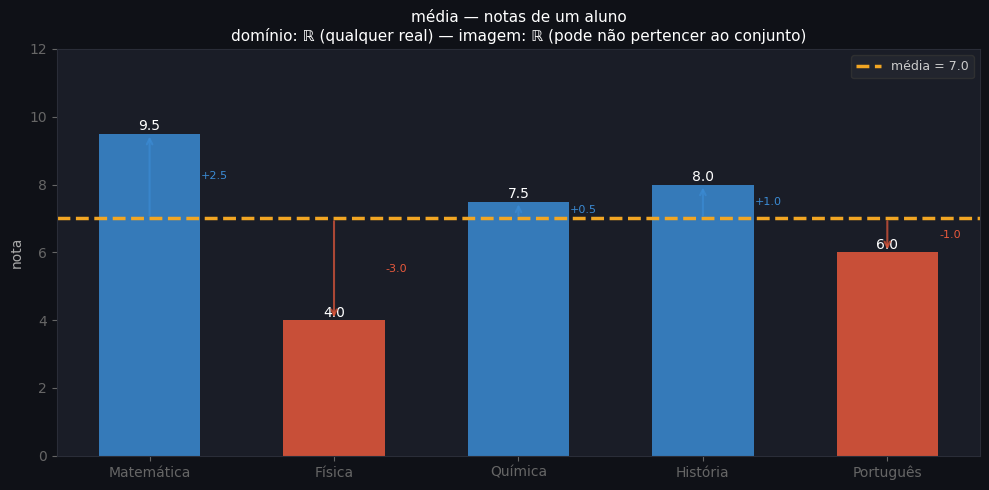

── Média ────────────────────────────────────
Conjunto : [9.5, 4.0, 7.5, 8.0, 6.0]
Média    : 7.0
Domínio  : ℝ — qualquer número real
Imagem   : ℝ — pode NÃO pertencer ao conjunto original
Exemplo  : nenhuma prova teve nota 7.0, mas é a média


In [47]:


provas  = ['Matemática', 'Física', 'Química', 'História', 'Português']
notas   = [9.5, 4.0, 7.5, 8.0, 6.0]
media   = np.mean(notas)

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d27')

cores = ['#E8593C' if n < media else '#3B8BD4' for n in notas]
bars  = ax.bar(provas, notas, color=cores, width=0.55, edgecolor='none', alpha=0.85)

for bar, val in zip(bars, notas):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val}', ha='center', color='white', fontsize=10)

ax.axhline(media, color='#F2A623', linewidth=2.5, linestyle='--',
           label=f'média = {media:.1f}')

# Setas de desvio
for i, (nota, prova) in enumerate(zip(notas, provas)):
    cor = '#E8593C' if nota < media else '#3B8BD4'
    ax.annotate('', xy=(i, nota), xytext=(i, media),
                arrowprops=dict(arrowstyle='->', color=cor, lw=1.5, alpha=0.7))
    ax.text(i + 0.28, (nota + media) / 2,
            f'{nota-media:+.1f}', color=cor, fontsize=8, va='center')

ax.set_ylim(0, 12)
ax.set_ylabel('nota', color='#aaa')
ax.set_title('média — notas de um aluno\n'
             'domínio: ℝ (qualquer real) — imagem: ℝ (pode não pertencer ao conjunto)',
             color='white', fontsize=11)
ax.tick_params(colors='#666')
for spine in ax.spines.values(): spine.set_edgecolor('#2a2d38')
ax.legend(fontsize=9, facecolor='#252830', labelcolor='#ccc', edgecolor='#333')

plt.tight_layout()
plt.show()

print("── Média ────────────────────────────────────")
print(f"Conjunto : {notas}")
print(f"Média    : {media:.1f}")
print(f"Domínio  : ℝ — qualquer número real")
print(f"Imagem   : ℝ — pode NÃO pertencer ao conjunto original")
print(f"Exemplo  : nenhuma prova teve nota {media:.1f}, mas é a média")

# Moda: Sabores de sorvete pedidos

Caso curioso: empate entre Chocolate e Morango cria uma distribuição bimodal — a moda é a única estatística que pode retornar mais de um valor e que funciona com dados categóricos (texto).


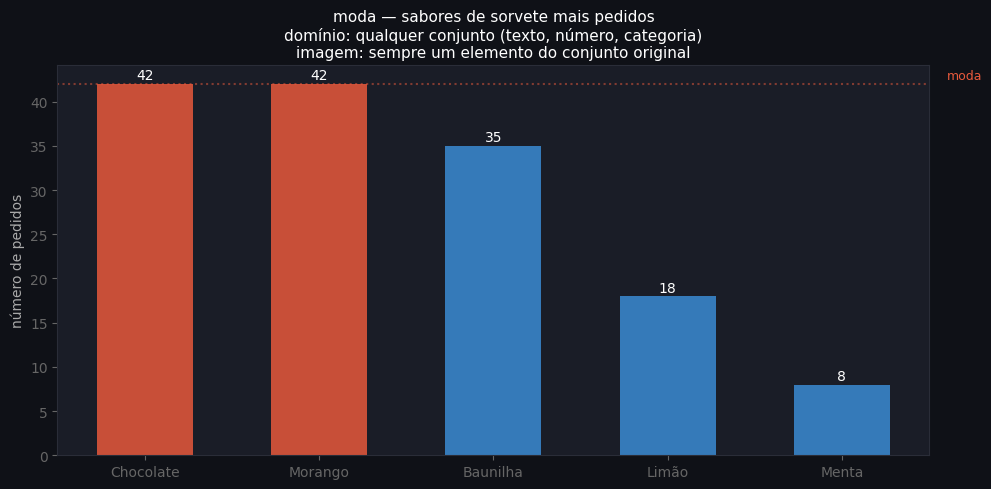

── Moda ─────────────────────────────────────
Pedidos  : {'Chocolate': 42, 'Morango': 42, 'Baunilha': 35, 'Limão': 18, 'Menta': 8}
Moda     : Chocolate e Morango (ambos com 42 pedidos)
Domínio  : qualquer tipo — funciona com texto e categorias
Imagem   : sempre pertence ao conjunto original
Caso especial: distribuição BIMODAL (dois valores empatados)


In [48]:


sabores    = ['Chocolate', 'Morango', 'Baunilha', 'Limão', 'Menta']
pedidos    = [42, 42, 35, 18, 8]
moda_idx   = np.argmax(pedidos)

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d27')

cores = ['#E8593C' if i == moda_idx or pedidos[i] == pedidos[moda_idx]
         else '#3B8BD4' for i in range(len(sabores))]
bars  = ax.bar(sabores, pedidos, color=cores, width=0.55, edgecolor='none', alpha=0.85)

for bar, val in zip(bars, pedidos):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(val), ha='center', color='white', fontsize=10)

ax.axhline(max(pedidos), color='#E8593C', linestyle=':', linewidth=1.5, alpha=0.5)
ax.text(4.6, max(pedidos)+0.5, 'moda', color='#E8593C', fontsize=9)

ax.set_ylabel('número de pedidos', color='#aaa')
ax.set_title('moda — sabores de sorvete mais pedidos\n'
             'domínio: qualquer conjunto (texto, número, categoria)\n'
             'imagem: sempre um elemento do conjunto original',
             color='white', fontsize=11)
ax.tick_params(colors='#666')
for spine in ax.spines.values(): spine.set_edgecolor('#2a2d38')

plt.tight_layout()
plt.show()

print("── Moda ─────────────────────────────────────")
print(f"Pedidos  : {dict(zip(sabores, pedidos))}")
print(f"Moda     : Chocolate e Morango (ambos com 42 pedidos)")
print(f"Domínio  : qualquer tipo — funciona com texto e categorias")
print(f"Imagem   : sempre pertence ao conjunto original")
print(f"Caso especial: distribuição BIMODAL (dois valores empatados)")

# Mediana — Salários

Caso curioso: o salário do CTO (R85.000) infla a média para R21.900 — mais do que qualquer funcionário ganha exceto o próprio CTO. A mediana (R7.000) representa melhor a realidade da maioria.

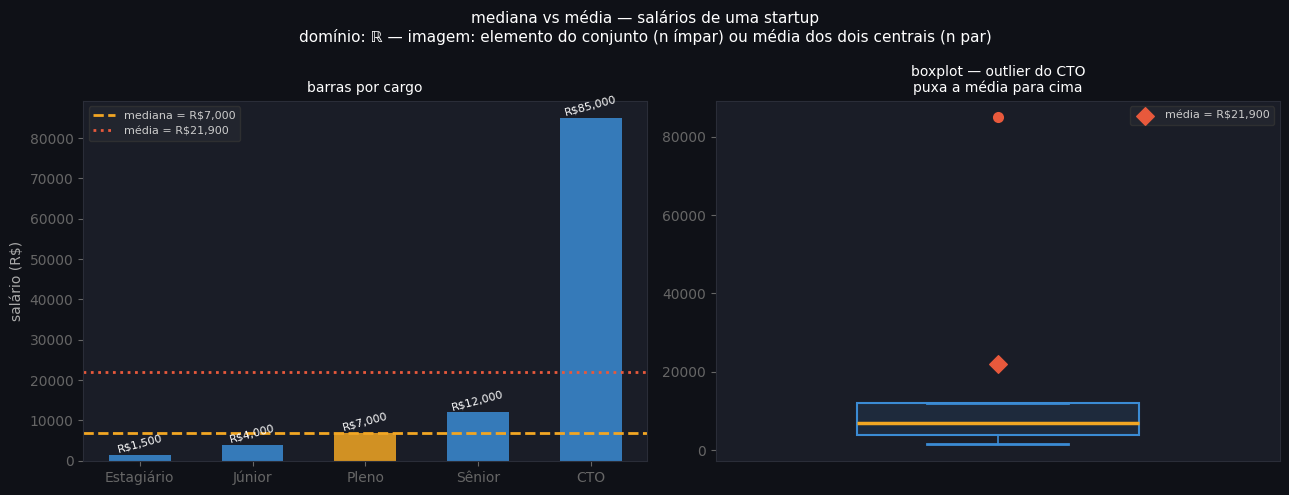

── Mediana ──────────────────────────────────
Salários : [1500, 4000, 7000, 12000, 85000]
Mediana  : R$7,000  ← valor central real
Média    : R$21,900 ← inflada pelo CTO
Domínio  : ℝ
Imagem   : elemento do conjunto (n ímpar) OU média dos dois centrais (n par)


In [52]:


cargos   = ['Estagiário', 'Júnior', 'Pleno', 'Sênior', 'CTO']
salarios = [1500, 4000, 7000, 12000, 85000]
mediana  = np.median(salarios)
media    = np.mean(salarios)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('#0f1117')

for ax in axes:
    ax.set_facecolor('#1a1d27')
    ax.tick_params(colors='#666')
    for spine in ax.spines.values(): spine.set_edgecolor('#2a2d38')

# Painel 1: barras
cores = ['#3B8BD4'] * len(salarios)
cores[2] = '#F2A623'  # mediana
bars = axes[0].bar(cargos, salarios, color=cores, width=0.55, edgecolor='none', alpha=0.85)
for bar, val in zip(bars, salarios):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'R${val:,}', ha='center', color='white', fontsize=8,
                 rotation=15)
axes[0].axhline(mediana, color='#F2A623', linewidth=2, linestyle='--',
                label=f'mediana = R${mediana:,.0f}')
axes[0].axhline(media, color='#E8593C', linewidth=2, linestyle=':',
                label=f'média = R${media:,.0f}')
axes[0].set_title('barras por cargo', color='white', fontsize=10)
axes[0].set_ylabel('salário (R$)', color='#aaa')
axes[0].legend(fontsize=8, facecolor='#252830', labelcolor='#ccc', edgecolor='#333')

# Painel 2: boxplot com ponto da média
axes[1].boxplot(salarios, vert=True, patch_artist=True, widths=0.5,
                boxprops=dict(facecolor='#3B8BD420', edgecolor='#3B8BD4', linewidth=1.5),
                medianprops=dict(color='#F2A623', linewidth=2.5),
                whiskerprops=dict(color='#3B8BD4', linewidth=1.2),
                capprops=dict(color='#3B8BD4', linewidth=2),
                flierprops=dict(marker='o', markerfacecolor='#E8593C',
                                markeredgecolor='none', markersize=8))
axes[1].scatter([1], [media], color='#E8593C', s=80, zorder=5,
                marker='D', label=f'média = R${media:,.0f}')
axes[1].set_title('boxplot — outlier do CTO\npuxa a média para cima',
                  color='white', fontsize=10)
axes[1].set_xticks([])
axes[1].legend(fontsize=8, facecolor='#252830', labelcolor='#ccc', edgecolor='#333')

fig.suptitle('mediana vs média — salários de uma startup\n'
             'domínio: ℝ — imagem: elemento do conjunto (n ímpar) ou média dos dois centrais (n par)',
             color='white', fontsize=11)
plt.tight_layout()
plt.show()

print("── Mediana ──────────────────────────────────")
print(f"Salários : {salarios}")
print(f"Mediana  : R${mediana:,.0f}  ← valor central real")
print(f"Média    : R${media:,.0f} ← inflada pelo CTO")
print(f"Domínio  : ℝ")
print(f"Imagem   : elemento do conjunto (n ímpar) OU média dos dois centrais (n par)")

# Range Temperaturas

Caso curioso: Gramado tem range de 27°C o maior de todos apesar de ter o menor máximo. Isso mostra que range mede variabilidade, não magnitude absoluta.

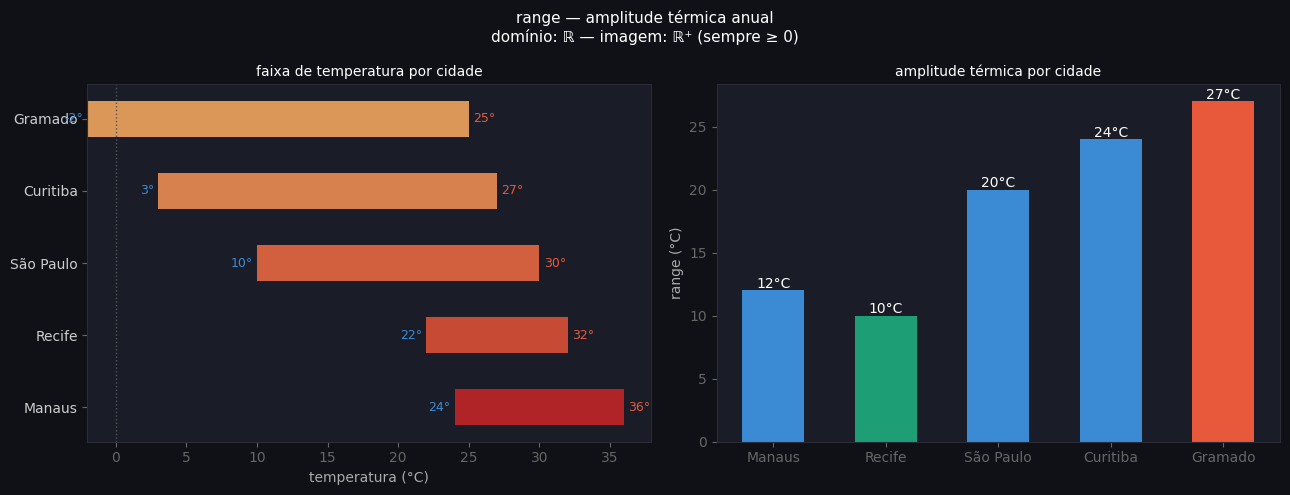

── Range ────────────────────────────────────
Manaus      : min=24°C  max=36°C  range=12°C
Recife      : min=22°C  max=32°C  range=10°C
São Paulo   : min=10°C  max=30°C  range=20°C
Curitiba    : min=3°C  max=27°C  range=24°C
Gramado     : min=-2°C  max=25°C  range=27°C

Domínio : ℝ (temperaturas podem ser negativas)
Imagem  : ℝ⁺ — range é sempre ≥ 0 (max ≥ min por definição)


In [51]:


cidades = ['Manaus', 'Recife', 'São Paulo', 'Curitiba', 'Gramado']
temp_min = [24, 22, 10, 3, -2]
temp_max = [36, 32, 30, 27, 25]
ranges   = [mx - mn for mx, mn in zip(temp_max, temp_min)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('#0f1117')

for ax in axes:
    ax.set_facecolor('#1a1d27')
    ax.tick_params(colors='#666')
    for spine in ax.spines.values(): spine.set_edgecolor('#2a2d38')

# Painel 1: faixas de temperatura
for i, (cidade, mn, mx) in enumerate(zip(cidades, temp_min, temp_max)):
    axes[0].barh(i, mx - mn, left=mn, height=0.5,
                 color=plt.cm.RdYlBu_r((mx + 10) / 50), alpha=0.85)
    axes[0].text(mx + 0.3, i, f'{mx}°', va='center', color='#E8593C', fontsize=9)
    axes[0].text(mn - 0.3, i, f'{mn}°', va='center', ha='right',
                 color='#3B8BD4', fontsize=9)

axes[0].set_yticks(range(len(cidades)))
axes[0].set_yticklabels(cidades, color='#ccc')
axes[0].axvline(0, color='#555', linewidth=1, linestyle=':')
axes[0].set_xlabel('temperatura (°C)', color='#aaa')
axes[0].set_title('faixa de temperatura por cidade', color='white', fontsize=10)

# Painel 2: range por cidade
cores_range = ['#E8593C' if r == max(ranges) else
               '#1D9E75' if r == min(ranges) else '#3B8BD4' for r in ranges]
bars = axes[1].bar(cidades, ranges, color=cores_range, width=0.55, edgecolor='none')
for bar, val in zip(bars, ranges):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{val}°C', ha='center', color='white', fontsize=10)
axes[1].set_ylabel('range (°C)', color='#aaa')
axes[1].set_title('amplitude térmica por cidade', color='white', fontsize=10)

fig.suptitle('range — amplitude térmica anual\n'
             'domínio: ℝ — imagem: ℝ⁺ (sempre ≥ 0)',
             color='white', fontsize=11)
plt.tight_layout()
plt.show()

print("── Range ────────────────────────────────────")
for c, mn, mx, r in zip(cidades, temp_min, temp_max, ranges):
    print(f"{c:<12}: min={mn}°C  max={mx}°C  range={r}°C")
print(f"\nDomínio : ℝ (temperaturas podem ser negativas)")
print(f"Imagem  : ℝ⁺ — range é sempre ≥ 0 (max ≥ min por definição)")

# Soma: Calorias ingeridas na semana

Caso curioso: mesmo respeitando a meta em 2 dias (segunda e terça), a soma semanal revela um excesso de 650 kcal. A soma é a única estatística que captura o efeito acumulado ao longo do tempo.


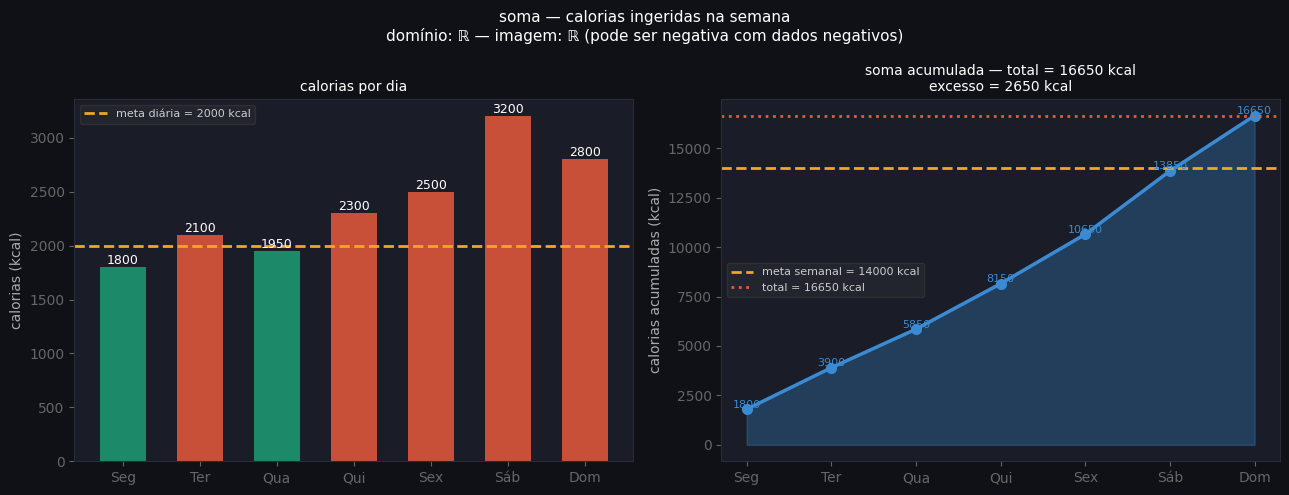

── Soma ─────────────────────────────────────
Calorias : [1800, 2100, 1950, 2300, 2500, 3200, 2800]
Soma     : 16650 kcal
Meta     : 14000 kcal
Excesso  : 2650 kcal
Domínio  : ℝ — funciona com qualquer número real
Imagem   : ℝ — pode ser negativa se os dados forem negativos


In [53]:

dias      = ['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom']
calorias  = [1800, 2100, 1950, 2300, 2500, 3200, 2800]
meta_dia  = 2000
soma      = sum(calorias)
meta_sem  = meta_dia * 7

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('#0f1117')

for ax in axes:
    ax.set_facecolor('#1a1d27')
    ax.tick_params(colors='#666')
    for spine in ax.spines.values(): spine.set_edgecolor('#2a2d38')

# Painel 1: barras diárias
cores = ['#E8593C' if c > meta_dia else '#1D9E75' for c in calorias]
bars  = axes[0].bar(dias, calorias, color=cores, width=0.6, edgecolor='none', alpha=0.85)
for bar, val in zip(bars, calorias):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 str(val), ha='center', color='white', fontsize=9)
axes[0].axhline(meta_dia, color='#F2A623', linewidth=2, linestyle='--',
                label=f'meta diária = {meta_dia} kcal')
axes[0].set_ylabel('calorias (kcal)', color='#aaa')
axes[0].set_title('calorias por dia', color='white', fontsize=10)
axes[0].legend(fontsize=8, facecolor='#252830', labelcolor='#ccc', edgecolor='#333')

# Painel 2: acumulado
acumulado = np.cumsum(calorias)
axes[1].fill_between(range(7), acumulado, alpha=0.3, color='#3B8BD4')
axes[1].plot(range(7), acumulado, color='#3B8BD4', linewidth=2.5,
             marker='o', markersize=7)
axes[1].axhline(meta_sem, color='#F2A623', linewidth=2, linestyle='--',
                label=f'meta semanal = {meta_sem} kcal')
axes[1].axhline(soma, color='#E8593C', linewidth=2, linestyle=':',
                label=f'total = {soma} kcal')

for i, (val, ac) in enumerate(zip(calorias, acumulado)):
    axes[1].text(i, ac + 80, str(ac), ha='center', color='#3B8BD4', fontsize=8)

axes[1].set_xticks(range(7))
axes[1].set_xticklabels(dias)
axes[1].set_ylabel('calorias acumuladas (kcal)', color='#aaa')
axes[1].set_title(f'soma acumulada — total = {soma} kcal\n'
                  f'excesso = {soma - meta_sem} kcal', color='white', fontsize=10)
axes[1].legend(fontsize=8, facecolor='#252830', labelcolor='#ccc', edgecolor='#333')

fig.suptitle('soma — calorias ingeridas na semana\n'
             'domínio: ℝ — imagem: ℝ (pode ser negativa com dados negativos)',
             color='white', fontsize=11)
plt.tight_layout()
plt.show()

print("── Soma ─────────────────────────────────────")
print(f"Calorias : {calorias}")
print(f"Soma     : {soma} kcal")
print(f"Meta     : {meta_sem} kcal")
print(f"Excesso  : {soma - meta_sem} kcal")
print(f"Domínio  : ℝ — funciona com qualquer número real")
print(f"Imagem   : ℝ — pode ser negativa se os dados forem negativos")

# Variância e Desvio Padrão Pontaria de dois arqueiros


Caso curioso: ambos os arqueiros têm médias similares (~55 pontos), mas o desvio padrão do Arqueiro B é quase 10x maior. A variância e o desvio padrão são as únicas estatísticas que capturam essa diferença de consistência — uma informação invisível na média.

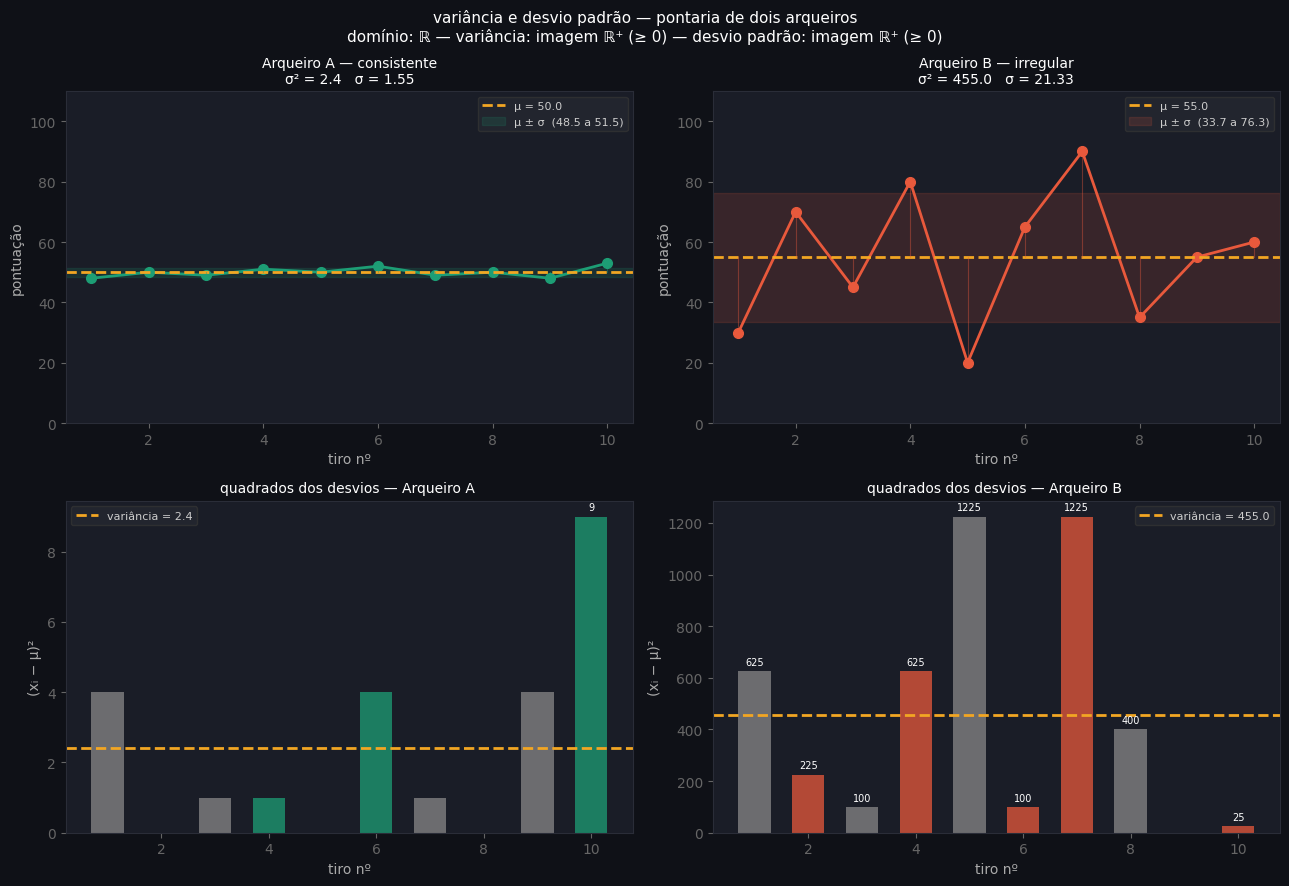


── Arqueiro A ─────────────────────────
  Tiros     : [np.int64(48), np.int64(50), np.int64(49), np.int64(51), np.int64(50), np.int64(52), np.int64(49), np.int64(50), np.int64(48), np.int64(53)]
  Média     : 50.0
  Variância : 2.4  (unidade = pontos²)
  Desvio p. : 1.55 (unidade = pontos)
  Domínio   : ℝ
  Imagem    : ℝ⁺ — sempre ≥ 0 (quadrado nunca é negativo)

── Arqueiro B ─────────────────────────
  Tiros     : [np.int64(30), np.int64(70), np.int64(45), np.int64(80), np.int64(20), np.int64(65), np.int64(90), np.int64(35), np.int64(55), np.int64(60)]
  Média     : 55.0
  Variância : 455.0  (unidade = pontos²)
  Desvio p. : 21.33 (unidade = pontos)
  Domínio   : ℝ
  Imagem    : ℝ⁺ — sempre ≥ 0 (quadrado nunca é negativo)


In [54]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

arqueiro_A = np.array([48, 50, 49, 51, 50, 52, 49, 50, 48, 53])  # consistente
arqueiro_B = np.array([30, 70, 45, 80, 20, 65, 90, 35, 55, 60])  # irregular

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.patch.set_facecolor('#0f1117')

for ax in axes.flat:
    ax.set_facecolor('#1a1d27')
    ax.tick_params(colors='#666')
    for spine in ax.spines.values(): spine.set_edgecolor('#2a2d38')

tiros = range(1, 11)

for idx, (nome, dados, cor) in enumerate([
    ('Arqueiro A — consistente', arqueiro_A, '#1D9E75'),
    ('Arqueiro B — irregular',   arqueiro_B, '#E8593C')
]):
    media = np.mean(dados)
    var   = np.var(dados)
    dp    = np.std(dados)

    # Painel superior: série de tiros
    ax = axes[0][idx]
    ax.plot(tiros, dados, color=cor, linewidth=2, marker='o', markersize=7)
    ax.axhline(media, color='#F2A623', linewidth=2, linestyle='--',
               label=f'μ = {media:.1f}')
    ax.axhspan(media - dp, media + dp, alpha=0.15, color=cor,
               label=f'μ ± σ  ({media-dp:.1f} a {media+dp:.1f})')
    for t, v in zip(tiros, dados):
        ax.plot([t, t], [media, v], color=cor, linewidth=0.8, alpha=0.4)
    ax.set_title(f'{nome}\nσ² = {var:.1f}   σ = {dp:.2f}',
                 color='white', fontsize=10)
    ax.set_xlabel('tiro nº', color='#aaa')
    ax.set_ylabel('pontuação', color='#aaa')
    ax.set_ylim(0, 110)
    ax.legend(fontsize=8, facecolor='#252830', labelcolor='#ccc', edgecolor='#333')

    # Painel inferior: quadrados dos desvios
    ax2   = axes[1][idx]
    devs  = dados - media
    devs2 = devs ** 2
    cores_dev = [cor if d >= 0 else '#888' for d in devs]
    ax2.bar(tiros, devs2, color=cores_dev, alpha=0.75, width=0.6, edgecolor='none')
    ax2.axhline(var, color='#F2A623', linewidth=2, linestyle='--',
                label=f'variância = {var:.1f}')
    for t, v in zip(tiros, devs2):
        if v > 5:
            ax2.text(t, v + max(devs2)*0.02, f'{v:.0f}',
                     ha='center', color='white', fontsize=7)
    ax2.set_title(f'quadrados dos desvios — {nome.split("—")[0]}',
                  color='white', fontsize=10)
    ax2.set_xlabel('tiro nº', color='#aaa')
    ax2.set_ylabel('(xᵢ − μ)²', color='#aaa')
    ax2.legend(fontsize=8, facecolor='#252830', labelcolor='#ccc', edgecolor='#333')

fig.suptitle('variância e desvio padrão — pontaria de dois arqueiros\n'
             'domínio: ℝ — variância: imagem ℝ⁺ (≥ 0) — desvio padrão: imagem ℝ⁺ (≥ 0)',
             color='white', fontsize=11)
plt.tight_layout()
plt.show()

for nome, dados in [('Arqueiro A', arqueiro_A), ('Arqueiro B', arqueiro_B)]:
    print(f"\n── {nome} {'─'*(35-len(nome))}")
    print(f"  Tiros     : {list(dados)}")
    print(f"  Média     : {np.mean(dados):.1f}")
    print(f"  Variância : {np.var(dados):.1f}  (unidade = pontos²)")
    print(f"  Desvio p. : {np.std(dados):.2f} (unidade = pontos)")
    print(f"  Domínio   : ℝ")
    print(f"  Imagem    : ℝ⁺ — sempre ≥ 0 (quadrado nunca é negativo)")

# Média Móveis



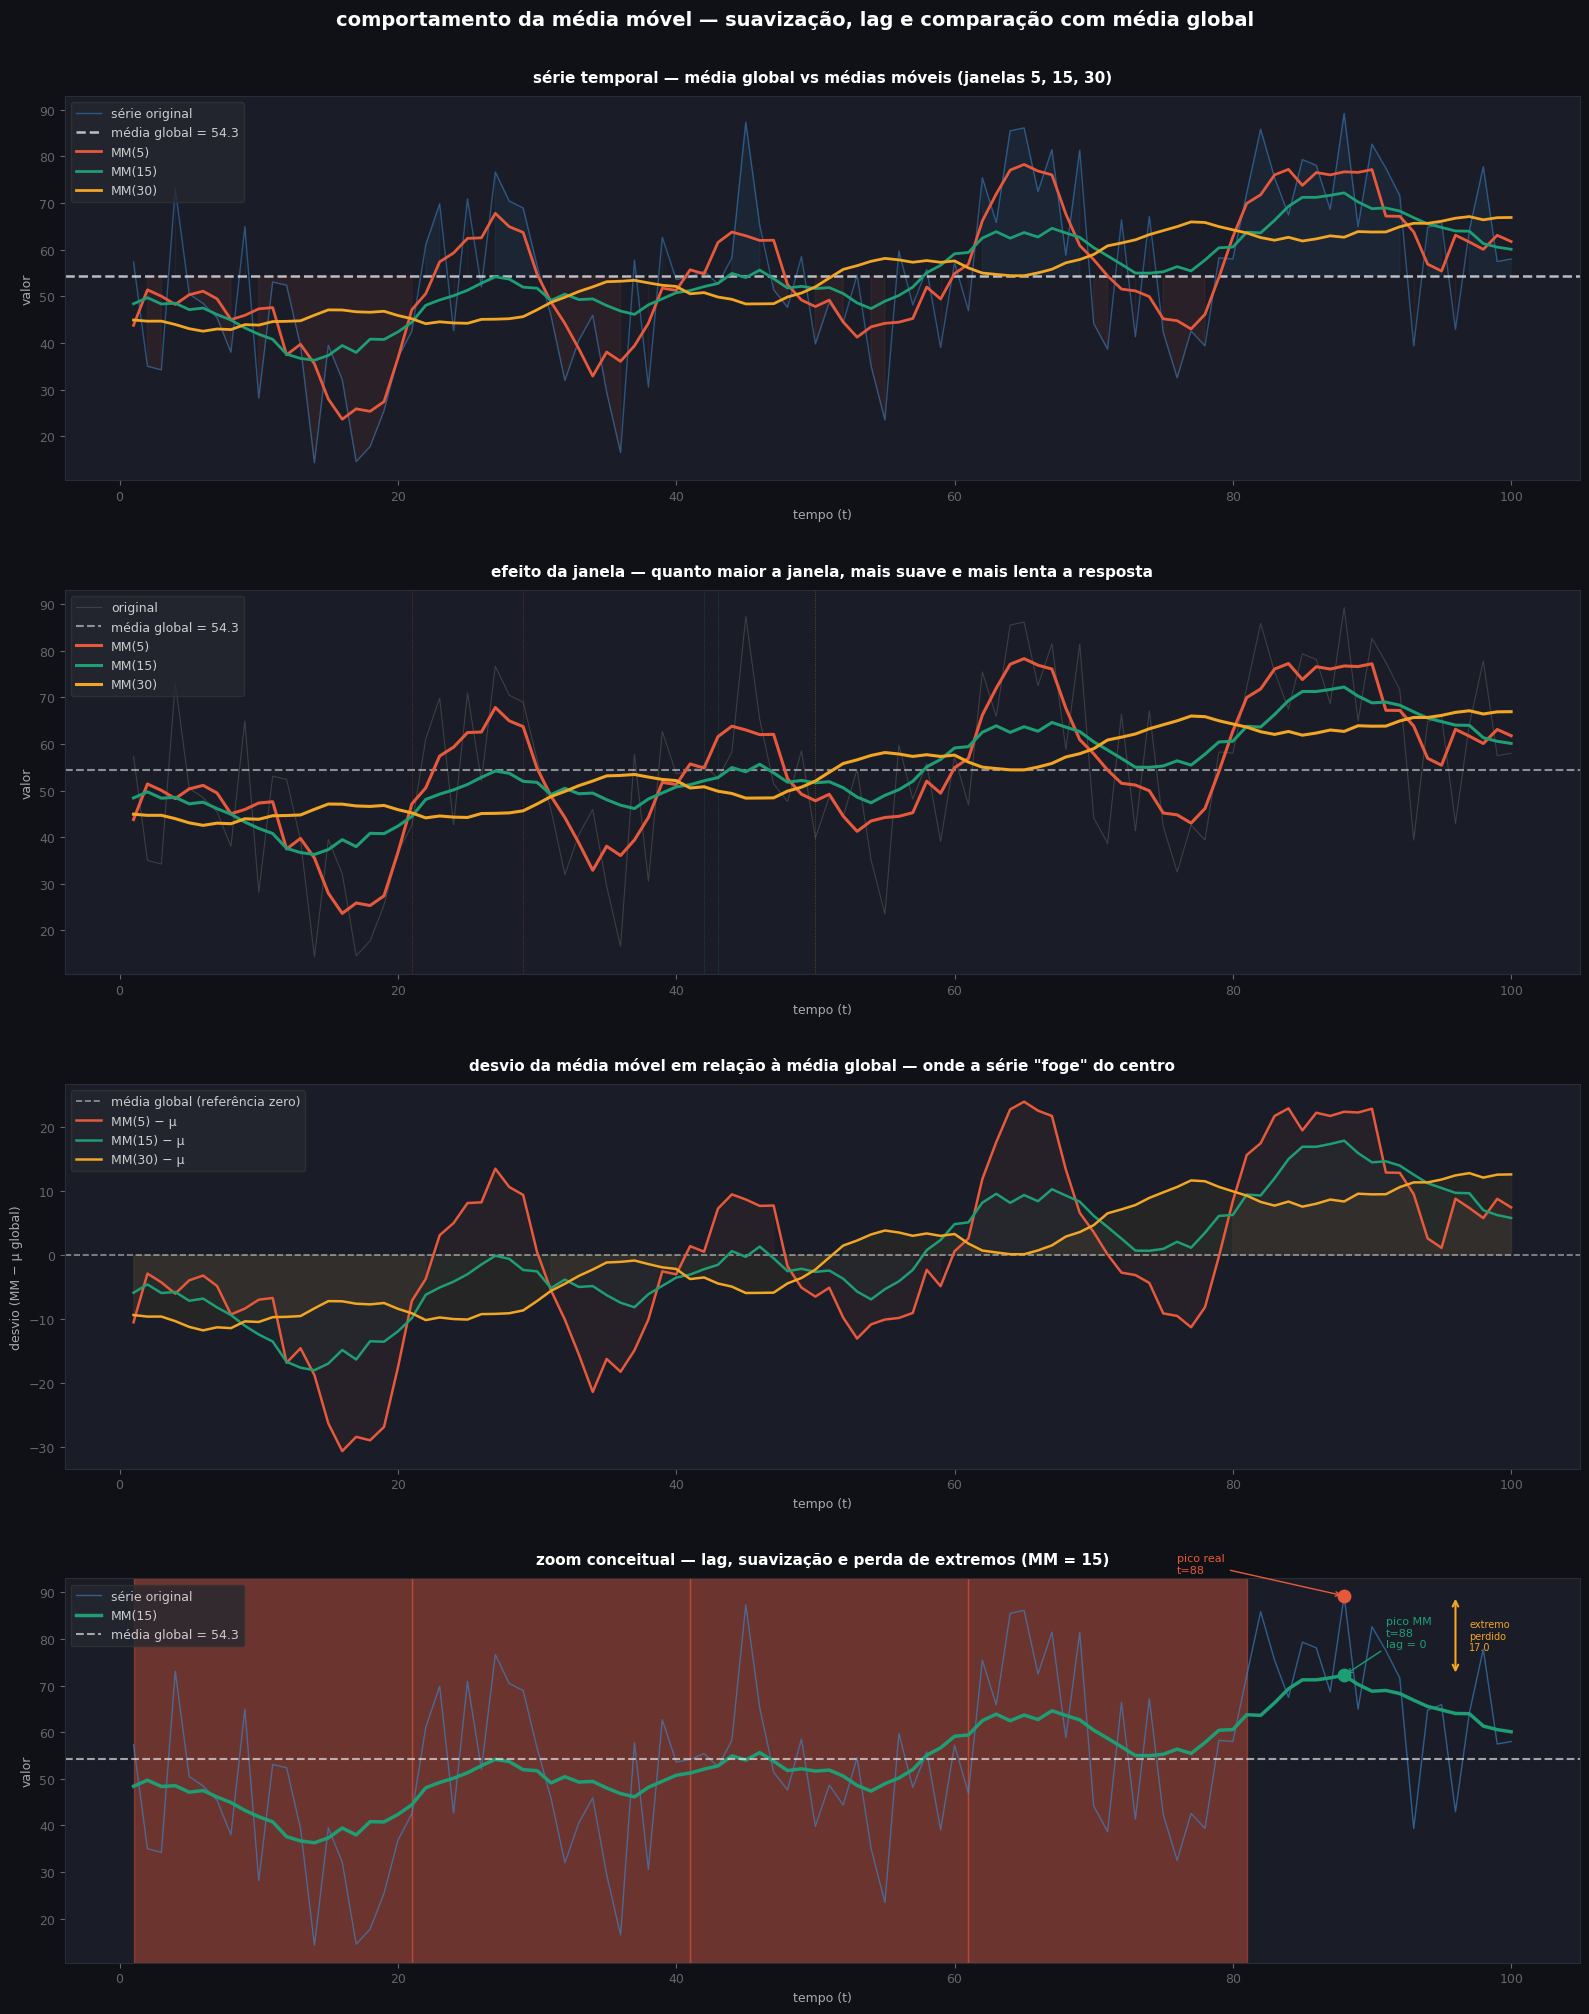

═══════════════════════════════════════════════════════
 DIAGNÓSTICO — MÉDIA GLOBAL vs MÉDIAS MÓVEIS
═══════════════════════════════════════════════════════

Métrica                             Valor
------------------------------------------
Média global                        54.31
Desvio padrão da série              17.70

──────────────────────────────────────────
  MM(janela=5)
  Média da MM                       54.31
  Desvio padrão da MM               13.24
  Redução do ruído                  25.2%
  Correlação com original          0.7836

──────────────────────────────────────────
  MM(janela=15)
  Média da MM                       54.31
  Desvio padrão da MM                8.90
  Redução do ruído                  49.7%
  Correlação com original          0.6563

──────────────────────────────────────────
  MM(janela=30)
  Média da MM                       54.20
  Desvio padrão da MM                7.84
  Redução do ruído                  55.7%
  Correlação com original       

In [55]:

from scipy.ndimage import uniform_filter1d


# ── Dados ────────────────────────────────────────────────────────────────────
rng    = random.Random(42)
n      = 100
tempo  = np.arange(1, n + 1)
ruido  = np.array([rng.randint(0, 100) for _ in range(n)], dtype=float)

# Série com tendência + sazonalidade + ruído (mais interessante que aleatória pura)
tendencia    = 0.3 * tempo
sazonalidade = 15 * np.sin(2 * np.pi * tempo / 20)
serie        = tendencia + sazonalidade + ruido * 0.4 + 20

media_global = np.mean(serie)

# Médias móveis com janelas diferentes
janelas = [5, 15, 30]
medias_moveis = {j: uniform_filter1d(serie, size=j) for j in janelas}

cores_mm = {5: '#E8593C', 15: '#1D9E75', 30: '#F2A623'}

# ── Figura principal ─────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 20))
fig.patch.set_facecolor('#0f1117')

def ax_style(ax, title):
    ax.set_facecolor('#1a1d27')
    ax.tick_params(colors='#666', labelsize=9)
    for spine in ax.spines.values():
        spine.set_edgecolor('#2a2d38')
    ax.set_title(title, color='white', fontsize=11, fontweight='bold', pad=10)
    ax.set_xlabel('tempo (t)', color='#aaa', fontsize=9)

# ────────────────────────────────────────────────────────────────────────────
# PAINEL 1 — série + todas as médias móveis + média global
# ────────────────────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(4, 1, 1)
ax_style(ax1, 'série temporal — média global vs médias móveis (janelas 5, 15, 30)')

ax1.plot(tempo, serie, color='#3B8BD4', linewidth=1, alpha=0.5, label='série original')
ax1.fill_between(tempo, serie, media_global, where=(serie >= media_global),
                 alpha=0.08, color='#3B8BD4')
ax1.fill_between(tempo, serie, media_global, where=(serie < media_global),
                 alpha=0.08, color='#E8593C')

ax1.axhline(media_global, color='white', linewidth=1.8, linestyle='--',
            alpha=0.7, label=f'média global = {media_global:.1f}')

for j in janelas:
    ax1.plot(tempo, medias_moveis[j], color=cores_mm[j], linewidth=2,
             label=f'MM({j})')

ax1.set_ylabel('valor', color='#aaa', fontsize=9)
ax1.legend(fontsize=9, facecolor='#252830', labelcolor='#ccc',
           edgecolor='#333', loc='upper left')

# ────────────────────────────────────────────────────────────────────────────
# PAINEL 2 — efeito do tamanho da janela lado a lado
# ────────────────────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(4, 1, 2)
ax_style(ax2, 'efeito da janela — quanto maior a janela, mais suave e mais lenta a resposta')

ax2.plot(tempo, serie, color='#555', linewidth=0.8, alpha=0.6, label='original')
ax2.axhline(media_global, color='white', linewidth=1.5, linestyle='--',
            alpha=0.5, label=f'média global = {media_global:.1f}')

for j in janelas:
    mm = medias_moveis[j]
    ax2.plot(tempo, mm, color=cores_mm[j], linewidth=2.2, label=f'MM({j})')

    # Anota o lag visual: ponto onde a MM cruza a média global
    cruzamentos = np.where(np.diff(np.sign(mm - media_global)))[0]
    for c in cruzamentos[:2]:
        ax2.axvline(c, color=cores_mm[j], linewidth=0.6, linestyle=':', alpha=0.4)

ax2.set_ylabel('valor', color='#aaa', fontsize=9)
ax2.legend(fontsize=9, facecolor='#252830', labelcolor='#ccc',
           edgecolor='#333', loc='upper left')

# ────────────────────────────────────────────────────────────────────────────
# PAINEL 3 — desvio da MM em relação à média global
# ────────────────────────────────────────────────────────────────────────────
ax3 = fig.add_subplot(4, 1, 3)
ax_style(ax3, 'desvio da média móvel em relação à média global — onde a série "foge" do centro')

ax3.axhline(0, color='white', linewidth=1.2, linestyle='--', alpha=0.5,
            label='média global (referência zero)')

for j in janelas:
    desvio = medias_moveis[j] - media_global
    ax3.plot(tempo, desvio, color=cores_mm[j], linewidth=1.8, label=f'MM({j}) − μ')
    ax3.fill_between(tempo, desvio, 0,
                     where=(desvio >= 0), alpha=0.06, color=cores_mm[j])
    ax3.fill_between(tempo, desvio, 0,
                     where=(desvio < 0),  alpha=0.06, color=cores_mm[j])

ax3.set_ylabel('desvio (MM − μ global)', color='#aaa', fontsize=9)
ax3.legend(fontsize=9, facecolor='#252830', labelcolor='#ccc',
           edgecolor='#333', loc='upper left')

# ────────────────────────────────────────────────────────────────────────────
# PAINEL 4 — comparação direta: série vs MM(15) vs média global
#            com anotações de lag e zonas de tendência
# ────────────────────────────────────────────────────────────────────────────
ax4 = fig.add_subplot(4, 1, 4)
ax_style(ax4, 'zoom conceitual — lag, suavização e perda de extremos (MM = 15)')

mm15 = medias_moveis[15]

# Zonas coloridas de tendência local
for i in range(0, n - 20, 20):
    tendencia_local = np.polyfit(tempo[i:i+20], serie[i:i+20], 1)[0]
    cor_zona = '#1D9E7520' if tendencia_local > 0 else '#E8593C20'
    ax4.axvspan(i+1, i+21, color=cor_zona, alpha=0.4)

ax4.plot(tempo, serie, color='#3B8BD4', linewidth=1, alpha=0.6, label='série original')
ax4.plot(tempo, mm15,  color='#1D9E75', linewidth=2.5, label='MM(15)')
ax4.axhline(media_global, color='white', linewidth=1.5, linestyle='--',
            alpha=0.6, label=f'média global = {media_global:.1f}')

# Pico real e pico da MM — mostra o lag
pico_real = np.argmax(serie)
pico_mm   = np.argmax(mm15)
ax4.scatter(tempo[pico_real], serie[pico_real],
            color='#E8593C', s=80, zorder=5)
ax4.scatter(tempo[pico_mm],   mm15[pico_mm],
            color='#1D9E75',  s=80, zorder=5)
ax4.annotate(f'pico real\nt={tempo[pico_real]}',
             xy=(tempo[pico_real], serie[pico_real]),
             xytext=(tempo[pico_real] - 12, serie[pico_real] + 5),
             color='#E8593C', fontsize=8,
             arrowprops=dict(arrowstyle='->', color='#E8593C', lw=1))
ax4.annotate(f'pico MM\nt={tempo[pico_mm]}\nlag = {tempo[pico_mm]-tempo[pico_real]}',
             xy=(tempo[pico_mm], mm15[pico_mm]),
             xytext=(tempo[pico_mm] + 3, mm15[pico_mm] + 6),
             color='#1D9E75', fontsize=8,
             arrowprops=dict(arrowstyle='->', color='#1D9E75', lw=1))

# Extremos perdidos pela MM
max_serie = np.max(serie)
max_mm    = np.max(mm15)
ax4.annotate('', xy=(tempo[-5], max_serie), xytext=(tempo[-5], max_mm),
             arrowprops=dict(arrowstyle='<->', color='#F2A623', lw=1.5))
ax4.text(tempo[-5] + 1, (max_serie + max_mm) / 2,
         f'extremo\nperdido\n{max_serie - max_mm:.1f}',
         color='#F2A623', fontsize=7, va='center')

ax4.set_ylabel('valor', color='#aaa', fontsize=9)
ax4.legend(fontsize=9, facecolor='#252830', labelcolor='#ccc',
           edgecolor='#333', loc='upper left')

plt.suptitle('comportamento da média móvel — suavização, lag e comparação com média global',
             color='white', fontsize=14, fontweight='bold', y=1.005)
plt.tight_layout(h_pad=3)
plt.show()

# ── Tabela de diagnóstico ────────────────────────────────────────────────────
print("═" * 55)
print(" DIAGNÓSTICO — MÉDIA GLOBAL vs MÉDIAS MÓVEIS")
print("═" * 55)
print(f"\n{'Métrica':<30} {'Valor':>10}")
print("-" * 42)
print(f"{'Média global':<30} {media_global:>10.2f}")
print(f"{'Desvio padrão da série':<30} {np.std(serie):>10.2f}")
for j in janelas:
    mm  = medias_moveis[j]
    print(f"\n{'─'*42}")
    print(f"  MM(janela={j})")
    print(f"  {'Média da MM':<28} {np.mean(mm):>10.2f}")
    print(f"  {'Desvio padrão da MM':<28} {np.std(mm):>10.2f}")
    print(f"  {'Redução do ruído':<28} {(1 - np.std(mm)/np.std(serie))*100:>9.1f}%")
    print(f"  {'Correlação com original':<28} {np.corrcoef(serie, mm)[0,1]:>10.4f}")

# Partições

---

## Explicação

---

### 1. O que significa "cortar" um conjunto

Dado um conjunto de N=120 observações, dividimos em subconjuntos contíguos de tamanho k=10. Cada subconjunto é uma **amostra** do conjunto original. Para cada um calculamos a média — e o conjunto dessas médias é a **distribuição amostral das médias**.

---

### 2. A média é um operador linear?

Sim. A média satisfaz as duas propriedades que definem linearidade:

**Homogeneidade:** multiplicar todos os valores por uma constante multiplica a média pela mesma constante.

$$E[\alpha X] = \alpha \cdot E[X]$$

**Aditividade:** a média da soma de dois conjuntos é a soma das médias.

$$E[X + Y] = E[X] + E[Y]$$

O painel 4 demonstra isso graficamente — a relação entre `α` e `E[αX]` é uma **reta perfeita** passando pela origem. Não há curvatura, não há intercepto. Isso é linearidade pura.

---

### 3. A média das médias é igual à média global?

**Depende do tamanho dos subconjuntos.**

Se todos os subconjuntos têm o **mesmo tamanho k**, então sim — a média das médias é exatamente igual à média global:

$$\bar{x}_{global} = \frac{1}{n_{sub}} \sum_{i=1}^{n_{sub}} \bar{x}_i \quad \text{(subconjuntos iguais)}$$

A prova é direta — é apenas uma reordenação da soma:
```
μ_global  =  (x₁ + x₂ + ... + x₁₂₀) / 120
          =  [(x₁+...+x₁₀)/10 + (x₁₁+...+x₂₀)/10 + ...] / 12
          =  (μ₁ + μ₂ + ... + μ₁₂) / 12
          =  μ_das_μs  ✓

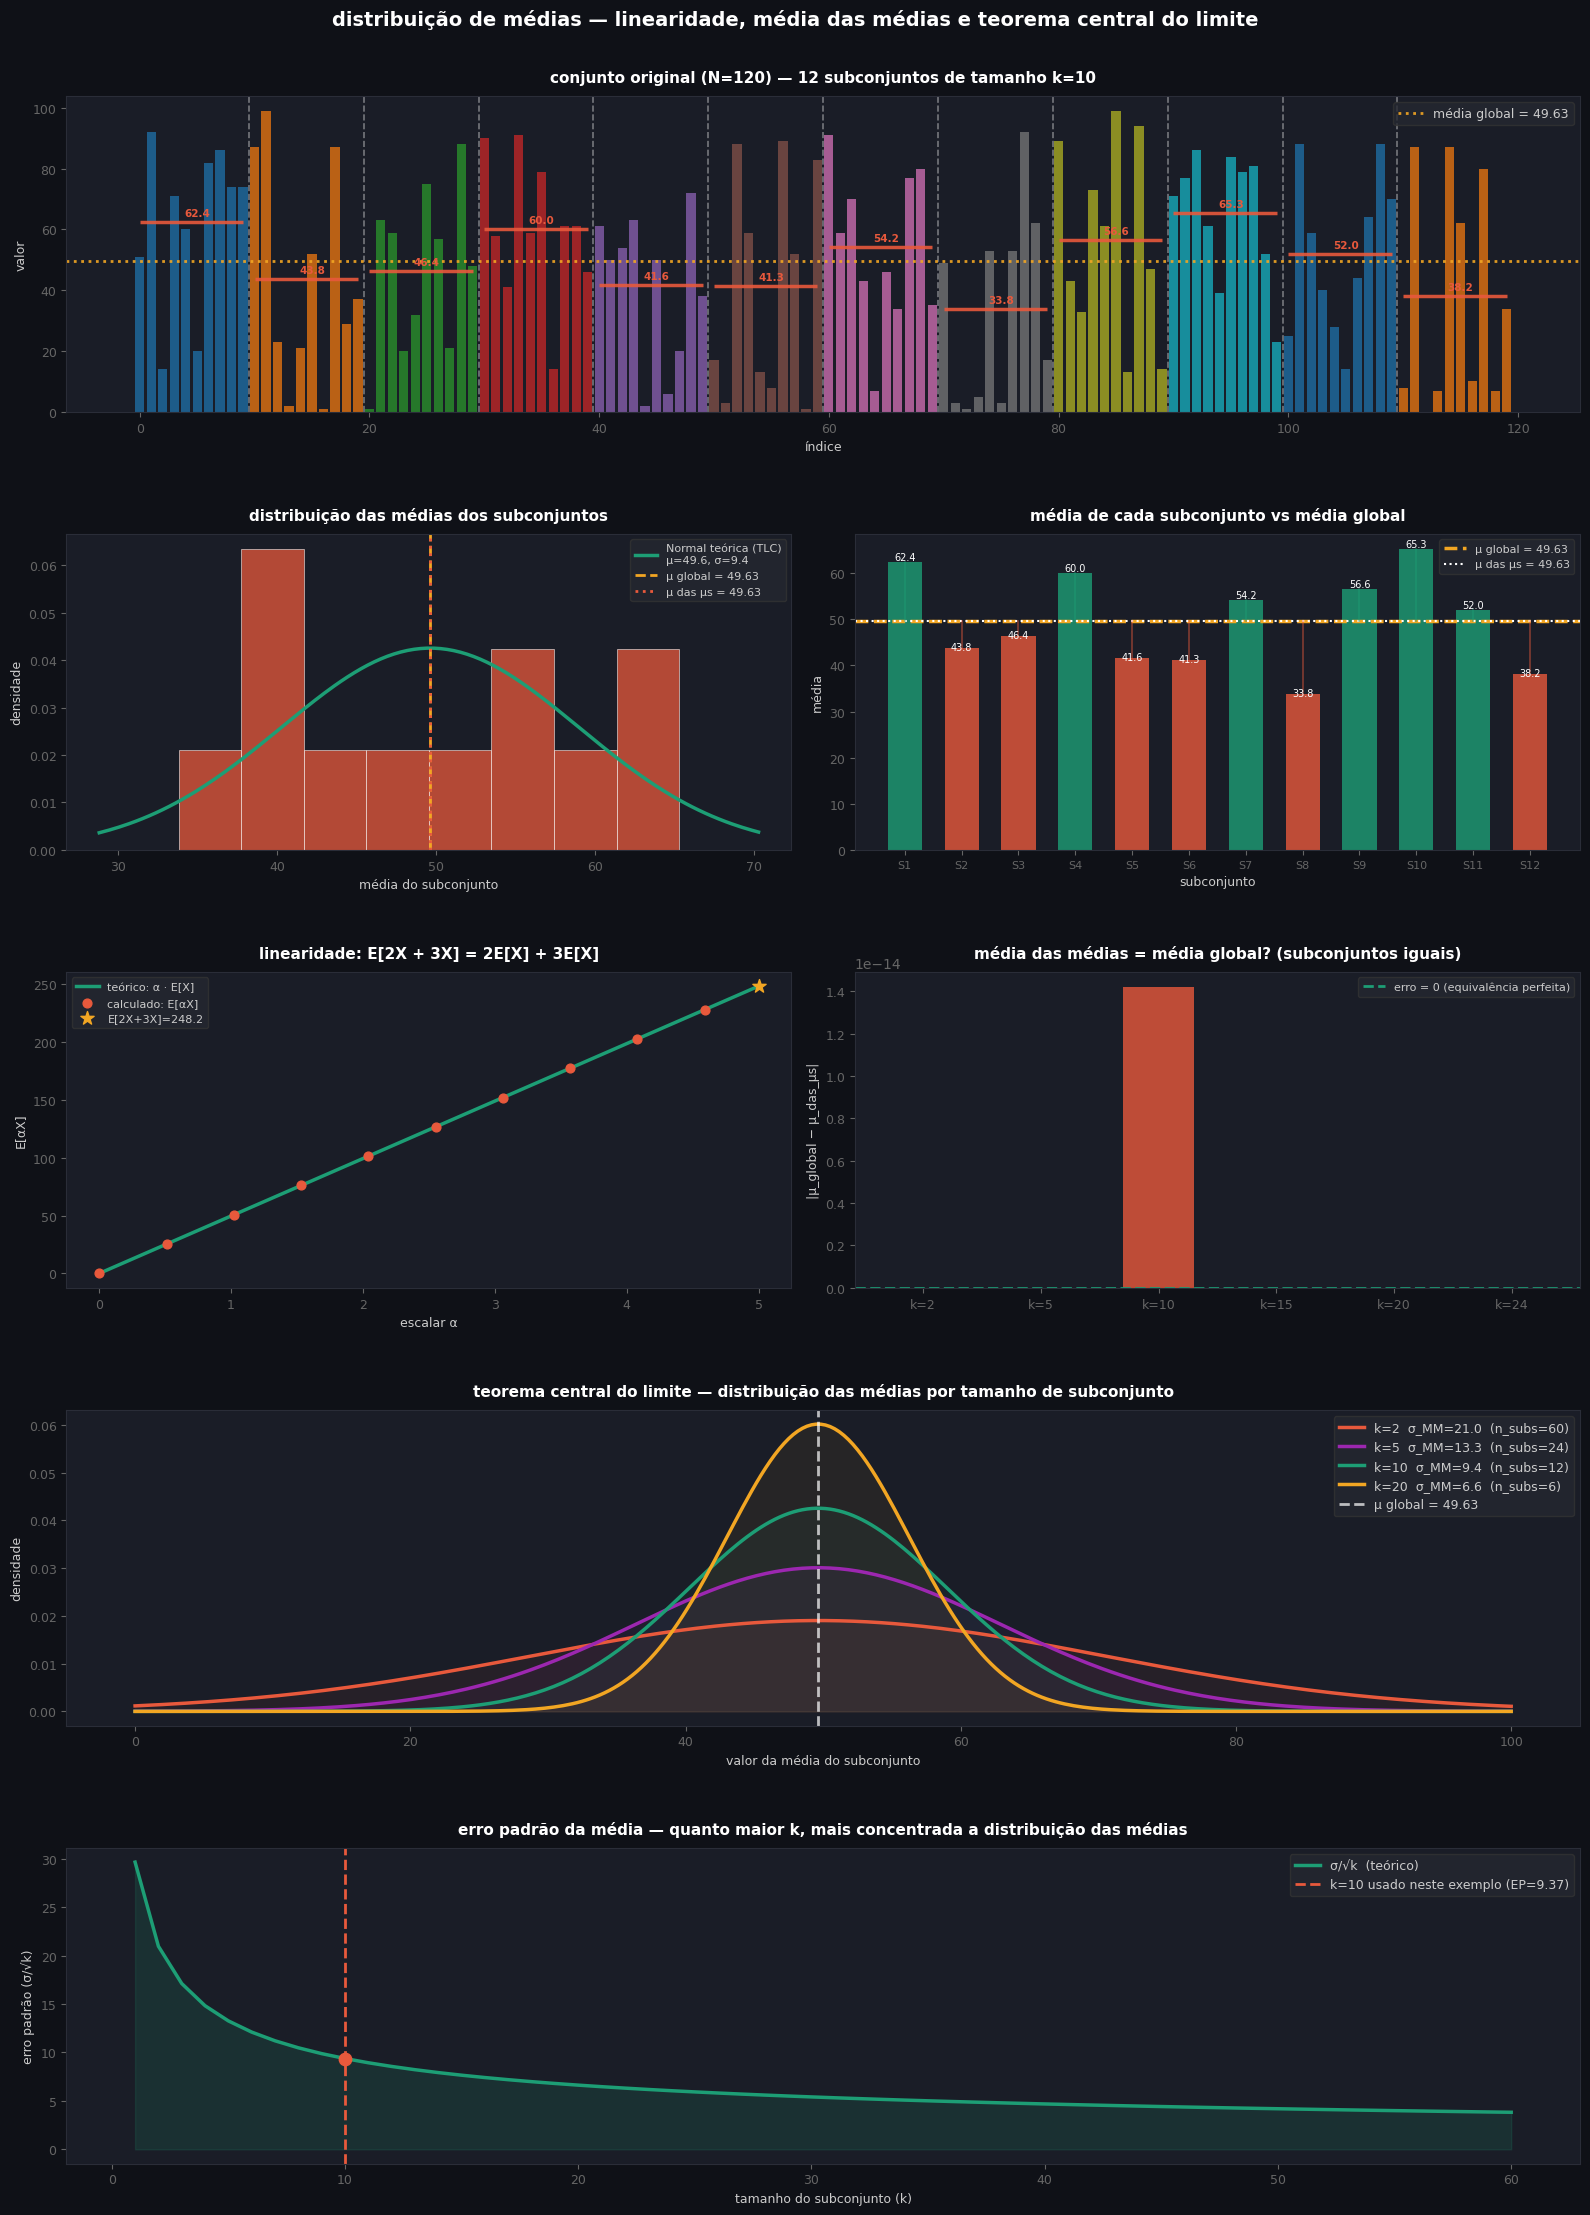

════════════════════════════════════════════════════════════
  DIAGNÓSTICO COMPLETO
════════════════════════════════════════════════════════════

  Conjunto original (N=120)
  Média global                        49.6333
  Desvio padrão original              29.6426

  Cortes em k=10 (n_sub=12 subconjuntos)
  Média das médias                    49.6333
  Diferença |μ_global − μ_das_μs|     0.000000
  São iguais? (tol=1e-10)             True

  Linearidade: E[2X + 3X]
  Teórico: ({a}+{b}) · E[X]           248.1667
  Calculado: E[{a:.0f}X + {b:.0f}X]   248.1667
  Diferença                           0.0000000000
  É linear? (tol=1e-10)               True

  Erro padrão (k=10)
  σ/√k (teórico)                      9.3738
  dp das médias (empírico)            9.7927


In [57]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

# ── Conjunto original ────────────────────────────────────────────────────────
N = 120
conjunto = np.random.randint(0, 100, size=N)

# ── Cortes em subconjuntos de tamanho k ──────────────────────────────────────
k = 10  # tamanho de cada subconjunto
n_sub = N // k
subconjuntos = [conjunto[i*k:(i+1)*k] for i in range(n_sub)]
medias_sub   = np.array([np.mean(s) for s in subconjuntos])

# ── Estatísticas centrais ─────────────────────────────────────────────────────
media_global        = np.mean(conjunto)
media_das_medias    = np.mean(medias_sub)
media_errada        = np.sum(medias_sub) / n_sub   # = media_das_medias (n igual)
media_ponderada     = np.sum([len(s)*np.mean(s) for s in subconjuntos]) / N

# ── Verificação da linearidade ───────────────────────────────────────────────
# Se média é linear: E[aX + bY] = aE[X] + bE[Y]
a, b   = 2.0, 3.0
conj_a = a * conjunto
conj_b = b * conjunto
media_linear_teorica = a * media_global + b * media_global
media_linear_real    = np.mean(conj_a + conj_b)

# ── Erro padrão da média ──────────────────────────────────────────────────────
erro_padrao = np.std(medias_sub) / np.sqrt(n_sub)

# ════════════════════════════════════════════════════════════════════════════
# FIGURA
# ════════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(16, 22))
fig.patch.set_facecolor('#0f1117')

def ax_style(ax, title):
    ax.set_facecolor('#1a1d27')
    ax.tick_params(colors='#666', labelsize=9)
    for spine in ax.spines.values():
        spine.set_edgecolor('#2a2d38')
    ax.set_title(title, color='white', fontsize=11, fontweight='bold', pad=10)

COR_ORIG   = '#3B8BD4'
COR_MEDIAS = '#E8593C'
COR_GLOBAL = '#F2A623'
COR_VERDE  = '#1D9E75'
COR_TEXTO  = '#cccccc'

# ────────────────────────────────────────────────────────────────────────────
# PAINEL 1 — conjunto original com cortes
# ────────────────────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(5, 1, 1)
ax_style(ax1, f'conjunto original (N={N}) — {n_sub} subconjuntos de tamanho k={k}')

cores_barras = []
cmap = plt.cm.tab10
for i in range(n_sub):
    cores_barras.extend([cmap(i % 10)] * k)

ax1.bar(range(N), conjunto, color=cores_barras, alpha=0.7,
        width=0.8, edgecolor='none')

# Linhas de corte
for i in range(1, n_sub):
    ax1.axvline(i*k - 0.5, color='white', linewidth=1.2,
                linestyle='--', alpha=0.4)

# Média de cada subconjunto
for i, m in enumerate(medias_sub):
    ax1.hlines(m, i*k, (i+1)*k - 1, colors=COR_MEDIAS,
               linewidth=2.5, alpha=0.9)
    ax1.text(i*k + k/2, m + 2, f'{m:.1f}',
             ha='center', color=COR_MEDIAS, fontsize=7.5, fontweight='bold')

ax1.axhline(media_global, color=COR_GLOBAL, linewidth=2,
            linestyle=':', alpha=0.9, label=f'média global = {media_global:.2f}')
ax1.set_ylabel('valor', color=COR_TEXTO, fontsize=9)
ax1.set_xlabel('índice', color=COR_TEXTO, fontsize=9)
ax1.legend(fontsize=9, facecolor='#252830', labelcolor='#ccc', edgecolor='#333')

# ────────────────────────────────────────────────────────────────────────────
# PAINEL 2 — distribuição das médias dos subconjuntos
# ────────────────────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(5, 2, 3)
ax_style(ax2, 'distribuição das médias dos subconjuntos')

ax2.hist(medias_sub, bins=8, color=COR_MEDIAS, alpha=0.75,
         edgecolor='white', linewidth=0.5, density=True)

# Curva normal teórica (TLC)
xmin, xmax = medias_sub.min() - 5, medias_sub.max() + 5
xs = np.linspace(xmin, xmax, 200)
mu_tlc  = media_global
sig_tlc = np.std(conjunto) / np.sqrt(k)
ax2.plot(xs, stats.norm.pdf(xs, mu_tlc, sig_tlc),
         color=COR_VERDE, linewidth=2.5,
         label=f'Normal teórica (TLC)\nμ={mu_tlc:.1f}, σ={sig_tlc:.1f}')

ax2.axvline(media_global,     color=COR_GLOBAL,  linewidth=2,
            linestyle='--', label=f'μ global = {media_global:.2f}')
ax2.axvline(media_das_medias, color=COR_MEDIAS,  linewidth=2,
            linestyle=':',  label=f'μ das μs = {media_das_medias:.2f}')

ax2.set_xlabel('média do subconjunto', color=COR_TEXTO, fontsize=9)
ax2.set_ylabel('densidade', color=COR_TEXTO, fontsize=9)
ax2.legend(fontsize=8, facecolor='#252830', labelcolor='#ccc', edgecolor='#333')

# ────────────────────────────────────────────────────────────────────────────
# PAINEL 3 — média por subconjunto vs média global
# ────────────────────────────────────────────────────────────────────────────
ax3 = fig.add_subplot(5, 2, 4)
ax_style(ax3, 'média de cada subconjunto vs média global')

cores_dev = [COR_VERDE if m >= media_global else COR_MEDIAS for m in medias_sub]
ax3.bar(range(n_sub), medias_sub, color=cores_dev, alpha=0.8,
        width=0.6, edgecolor='none')
ax3.axhline(media_global, color=COR_GLOBAL, linewidth=2.5,
            linestyle='--', label=f'μ global = {media_global:.2f}')
ax3.axhline(media_das_medias, color='white', linewidth=1.5,
            linestyle=':', label=f'μ das μs = {media_das_medias:.2f}')

for i, m in enumerate(medias_sub):
    ax3.plot([i, i], [media_global, m],
             color=cores_dev[i], linewidth=1.2, alpha=0.5)
    ax3.text(i, m + 0.5 * np.sign(m - media_global),
             f'{m:.1f}', ha='center', color='white', fontsize=7)

ax3.set_xlabel('subconjunto', color=COR_TEXTO, fontsize=9)
ax3.set_ylabel('média', color=COR_TEXTO, fontsize=9)
ax3.set_xticks(range(n_sub))
ax3.set_xticklabels([f'S{i+1}' for i in range(n_sub)], fontsize=8)
ax3.legend(fontsize=8, facecolor='#252830', labelcolor='#ccc', edgecolor='#333')

# ────────────────────────────────────────────────────────────────────────────
# PAINEL 4 — prova de linearidade: E[aX + bY] = aE[X] + bE[Y]
# ────────────────────────────────────────────────────────────────────────────
ax4 = fig.add_subplot(5, 2, 5)
ax_style(ax4, f'linearidade: E[{a:.0f}X + {b:.0f}X] = {a:.0f}E[X] + {b:.0f}E[X]')

escalas  = np.linspace(0, 5, 50)
teorico  = escalas * media_global
real_vals= [np.mean(e * conjunto) for e in escalas]

ax4.plot(escalas, teorico,  color=COR_VERDE,  linewidth=2.5,
         label='teórico: α · E[X]')
ax4.scatter(escalas[::5], real_vals[::5], color=COR_MEDIAS,
            s=40, zorder=5, label='calculado: E[αX]')
ax4.scatter([a+b], [media_linear_real], color=COR_GLOBAL,
            s=100, zorder=6, marker='*',
            label=f'E[{a:.0f}X+{b:.0f}X]={media_linear_real:.1f}')

ax4.set_xlabel('escalar α', color=COR_TEXTO, fontsize=9)
ax4.set_ylabel('E[αX]', color=COR_TEXTO, fontsize=9)
ax4.legend(fontsize=8, facecolor='#252830', labelcolor='#ccc', edgecolor='#333')

# ────────────────────────────────────────────────────────────────────────────
# PAINEL 5 — média das médias vs média global (subconjuntos iguais)
# ────────────────────────────────────────────────────────────────────────────
ax5 = fig.add_subplot(5, 2, 6)
ax_style(ax5, 'média das médias = média global? (subconjuntos iguais)')

ks_teste  = [2, 5, 10, 15, 20, 24]
erros_rel = []
for kt in ks_teste:
    if N % kt == 0:
        subs = [conjunto[i*kt:(i+1)*kt] for i in range(N//kt)]
        mm   = np.mean([np.mean(s) for s in subs])
        erros_rel.append(abs(mm - media_global))
    else:
        subs = [conjunto[i*kt:min((i+1)*kt, N)]
                for i in range(int(np.ceil(N/kt)))]
        mm   = np.average([np.mean(s) for s in subs],
                          weights=[len(s) for s in subs])
        erros_rel.append(abs(mm - media_global))

ax5.bar(range(len(ks_teste)), erros_rel, color=COR_MEDIAS,
        alpha=0.8, width=0.6, edgecolor='none')
ax5.axhline(0, color=COR_VERDE, linewidth=2, linestyle='--',
            label='erro = 0 (equivalência perfeita)')
ax5.set_xticks(range(len(ks_teste)))
ax5.set_xticklabels([f'k={k}' for k in ks_teste], fontsize=9)
ax5.set_ylabel('|μ_global − μ_das_μs|', color=COR_TEXTO, fontsize=9)
ax5.legend(fontsize=8, facecolor='#252830', labelcolor='#ccc', edgecolor='#333')

# ────────────────────────────────────────────────────────────────────────────
# PAINEL 6 — Teorema Central do Limite: distribuição das médias com k variável
# ────────────────────────────────────────────────────────────────────────────
ax6 = fig.add_subplot(5, 1, 4)
ax_style(ax6, 'teorema central do limite — distribuição das médias por tamanho de subconjunto')

ks_tlc = [2, 5, 10, 20]
cores_tlc = [COR_MEDIAS, '#9C27B0', COR_VERDE, COR_GLOBAL]
dp_original = np.std(conjunto)

for kt, cor in zip(ks_tlc, cores_tlc):
    n_subs_tlc = N // kt
    medias_tlc = [np.mean(conjunto[i*kt:(i+1)*kt]) for i in range(n_subs_tlc)]
    xs = np.linspace(0, 100, 300)
    sig = dp_original / np.sqrt(kt)
    ax6.plot(xs, stats.norm.pdf(xs, media_global, sig),
             color=cor, linewidth=2.5,
             label=f'k={kt}  σ_MM={sig:.1f}  (n_subs={n_subs_tlc})')
    ax6.fill_between(xs, stats.norm.pdf(xs, media_global, sig),
                     alpha=0.06, color=cor)

ax6.axvline(media_global, color='white', linewidth=2,
            linestyle='--', alpha=0.7, label=f'μ global = {media_global:.2f}')
ax6.set_xlabel('valor da média do subconjunto', color=COR_TEXTO, fontsize=9)
ax6.set_ylabel('densidade', color=COR_TEXTO, fontsize=9)
ax6.legend(fontsize=9, facecolor='#252830', labelcolor='#ccc',
           edgecolor='#333', loc='upper right')

# ────────────────────────────────────────────────────────────────────────────
# PAINEL 7 — erro padrão vs tamanho do subconjunto
# ────────────────────────────────────────────────────────────────────────────
ax7 = fig.add_subplot(5, 1, 5)
ax_style(ax7, 'erro padrão da média — quanto maior k, mais concentrada a distribuição das médias')

ks_ep   = np.arange(1, 61)
ep_real = dp_original / np.sqrt(ks_ep)
ax7.plot(ks_ep, ep_real, color=COR_VERDE, linewidth=2.5,
         label='σ/√k  (teórico)')
ax7.fill_between(ks_ep, ep_real, alpha=0.15, color=COR_VERDE)
ax7.axvline(k, color=COR_MEDIAS, linewidth=2, linestyle='--',
            label=f'k={k} usado neste exemplo (EP={dp_original/np.sqrt(k):.2f})')
ax7.scatter([k], [dp_original/np.sqrt(k)],
            color=COR_MEDIAS, s=80, zorder=5)
ax7.set_xlabel('tamanho do subconjunto (k)', color=COR_TEXTO, fontsize=9)
ax7.set_ylabel('erro padrão (σ/√k)', color=COR_TEXTO, fontsize=9)
ax7.legend(fontsize=9, facecolor='#252830', labelcolor='#ccc', edgecolor='#333')

plt.suptitle('distribuição de médias — linearidade, média das médias e teorema central do limite',
             color='white', fontsize=14, fontweight='bold', y=1.005)
plt.tight_layout(h_pad=3)
plt.show()

# ── Diagnóstico ───────────────────────────────────────────────────────────────
print("═" * 60)
print("  DIAGNÓSTICO COMPLETO")
print("═" * 60)
print(f"\n  Conjunto original (N={N})")
print(f"  {'Média global':<35} {media_global:.4f}")
print(f"  {'Desvio padrão original':<35} {np.std(conjunto):.4f}")

print(f"\n  Cortes em k={k} (n_sub={n_sub} subconjuntos)")
print(f"  {'Média das médias':<35} {media_das_medias:.4f}")
print(f"  {'Diferença |μ_global − μ_das_μs|':<35} {abs(media_global - media_das_medias):.6f}")
print(f"  {'São iguais? (tol=1e-10)':<35} {np.isclose(media_global, media_das_medias)}")

print(f"\n  Linearidade: E[{a:.0f}X + {b:.0f}X]")
print(f"  {'Teórico: ({a}+{b}) · E[X]':<35} {media_linear_teorica:.4f}")
print(f"  {'Calculado: E[{a:.0f}X + {b:.0f}X]':<35} {media_linear_real:.4f}")
print(f"  {'Diferença':<35} {abs(media_linear_teorica - media_linear_real):.10f}")
print(f"  {'É linear? (tol=1e-10)':<35} {np.isclose(media_linear_teorica, media_linear_real)}")

print(f"\n  Erro padrão (k={k})")
print(f"  {'σ/√k (teórico)':<35} {dp_original/np.sqrt(k):.4f}")
print(f"  {'dp das médias (empírico)':<35} {np.std(medias_sub):.4f}")